# Data Analysis

We have already performed some basic data preprocessing in the previous notebook. Now, we will dive deeper into the data to extract insights and understand the electoral and demographic landscape in Spain for the 2019 and 2023 general elections.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


from src.config import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
gdf = gpd.read_file(BASE_DIR / 'data' / 'processed' / 'combined_data.gpkg')
pd.options.display.float_format = '{:,.2f}'.format

## Dataset Overview
To get an overview of the dataset, we will check the shape of the GeoDataFrame, its information, and preview the first few rows. We also check for duplicates and missing values in the dataset to ensure data quality before proceeding with the analysis.

In [13]:
print('Shape of the GeoDataFrame:', gdf.shape)
gdf.info()
# Preview the data
display(gdf.head())

Shape of the GeoDataFrame: (8131, 26)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8131 entries, 0 to 8130
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Code of municipality                  8131 non-null   str     
 1   Name of municipality                  8131 non-null   str     
 2   Code of autonomous community          8131 non-null   str     
 3   Name of autonomous community          8131 non-null   str     
 4   Code of province                      8131 non-null   str     
 5   Name of province                      8131 non-null   str     
 6   Area in km2                           8131 non-null   float64 
 7   Latitude                              8131 non-null   float64 
 8   Longitude                             8131 non-null   float64 
 9   Population in 2023                    8131 non-null   float64 
 10  Mean age                  

,Code of municipality,Name of municipality,Code of autonomous community,Name of autonomous community,Code of province,Name of province,Area in km2,Latitude,Longitude,Population in 2023,...,Votes for PSOE in 2023 (%),Votes for VOX in 2023 (%),Votes for SUMAR in 2023 (%),Votes for PP in 2023 (%),Number of votes in 2019,Votes for PSOE in 2019 (%),Votes for VOX in 2019 (%),Votes for PP in 2019 (%),Votes for SUMAR in 2019 (%),geometry
0,01001,Alegría-Dulantzi,16,País Vasco-Euskadi,01,Araba-Álava,19.93,42.83,-2.51,"2,969.00",...,27.30,4.82,12.46,10.46,1372,20.70,3.94,8.31,18.15,"MULTIPOLYGON (((-2.52642 42.83195, -2.52663 42..."
1,01002,Amurrio,16,País Vasco-Euskadi,01,Araba-Álava,96.22,43.03,-2.97,"10,299.00",...,22.99,2.35,10.21,6.88,5786,16.07,2.66,5.84,14.97,"MULTIPOLYGON (((-3.01619 43.04059, -3.01575 43..."
2,01003,Aramaio,16,País Vasco-Euskadi,01,Araba-Álava,73.03,43.05,-2.59,"1,409.00",...,7.52,0.68,9.30,0.27,837,3.11,0.60,0.36,9.32,"MULTIPOLYGON (((-2.66113 43.06576, -2.66102 43..."
3,01004,Artziniega,16,País Vasco-Euskadi,01,Araba-Álava,27.26,43.13,-3.14,"1,832.00",...,19.76,3.33,11.09,10.38,945,11.43,3.49,8.89,15.56,"MULTIPOLYGON (((-3.14189 43.16115, -3.14159 43..."
4,01006,Armiñón,16,País Vasco-Euskadi,01,Araba-Álava,12.96,42.71,-2.87,233.00,...,20.90,11.19,14.18,23.13,122,16.39,14.75,17.21,22.95,"MULTIPOLYGON (((-2.8803 42.69937, -2.87852 42...."


In [14]:
# Check for exact duplicate rows
print(f"Duplicates: {gdf.duplicated().sum()}")

Duplicates: 0


In [16]:
# Check for missing values
print(gdf.isnull().sum())

Code of municipality                      0
Name of municipality                      0
Code of autonomous community              0
Name of autonomous community              0
Code of province                          0
Name of province                          0
Area in km2                               0
Latitude                                  0
Longitude                                 0
Population in 2023                        0
Mean age                                  0
Foreign-born population (%)               0
Population density (inhabitants/km2)      0
Population with higher education (%)    568
Mean net income per person               73
Number of votes in 2023                   0
Votes for PSOE in 2023 (%)                0
Votes for VOX in 2023 (%)                 0
Votes for SUMAR in 2023 (%)               0
Votes for PP in 2023 (%)                  0
Number of votes in 2019                   0
Votes for PSOE in 2019 (%)                0
Votes for VOX in 2019 (%)       

In [17]:
gdf.sum(numeric_only=True)

Area in km2                                505,278.03
Latitude                                   331,131.71
Longitude                                  -25,277.22
Population in 2023                      48,085,361.00
Mean age                                   410,732.64
Foreign-born population (%)                 81,003.23
Population density (inhabitants/km2)     1,481,523.54
Population with higher education (%)       197,940.07
Mean net income per person             116,797,631.00
Number of votes in 2023                 24,483,438.00
Votes for PSOE in 2023 (%)                 247,260.05
Votes for VOX in 2023 (%)                   99,701.04
Votes for SUMAR in 2023 (%)                 68,251.86
Votes for PP in 2023 (%)                   294,537.53
Number of votes in 2019                 24,113,264.00
Votes for PSOE in 2019 (%)                 233,059.45
Votes for VOX in 2019 (%)                  114,597.00
Votes for PP in 2019 (%)                   226,340.00
Votes for SUMAR in 2019 (%) 

Fortunately, our dataset is clean and does not contain any duplicates or missing values, which allows us to proceed with the analysis without needing to perform additional data cleaning steps.

## Demographic Analysis
In this section, we will perform the analysis of demographic variables.

In [6]:
# Dataset Overview
display(gdf.describe().T)

,count,mean,std,min,25%,50%,75%,max
objectid,"8,131.00","4,066.00","2,347.36",1.00,"2,033.50","4,066.00","6,098.50","8,131.00"
pob_npmun,"8,131.00",42.46,16.66,0.00,30.66,42.62,54.20,94.44
pob_23,"8,131.00","5,906.10","48,325.52",3.00,154.00,530.00,"2,435.50","3,332,035.00"
dens_pob,"8,131.00",181.96,931.00,0.23,4.65,13.44,56.63,"27,807.94"
edad_media,"8,131.00",50.51,6.63,34.66,45.12,49.80,55.41,75.12
afi_1000,"8,131.00",443.71,343.99,0.00,279.29,381.35,507.09,"7,293.24"
paro_1000,"8,131.00",69.12,42.94,0.00,40.28,64.73,92.08,"1,000.00"
porc_pob65,"8,131.00",29.41,10.94,5.27,20.87,27.96,36.67,80.00
pob_esup16,"8,131.00",22.83,10.97,0.00,16.28,22.07,29.34,63.41
porc_pob_e,"8,131.00",7.24,7.62,0.00,2.11,4.96,10.09,88.61


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

def plot_distribution(series, title=None, xlabel=None, source_text=None, color=None, 
                      scale='linear', limits=None, kde=True, ax=None, show_stats=True):
    """
    Displays summary statistics and plots a histogram with mean, median, and IQR.
    
    Parameters:
    - series: The pandas Series to plot.
    - title: String for the chart title.
    - xlabel: String for the x-axis label.
    - source_text: String for the source citation to display at the bottom right.
    - color: String for the histogram color.
    - scale: 'linear', 'log', or 'symlog'.
    - limits: Tuple for x-axis limits (e.g., (0, 100000)). None by default.
    - kde: Boolean to show or hide the Kernel Density Estimate curve.
    - ax: Matplotlib axes object to plot on (for subplots). If None, creates a new one.
    - show_stats: Boolean to show or hide the printed summary statistics.
    """
    
    sns.set_theme(style="white")

    # 1. Optionally display formatted summary statistics
    if show_stats:
        print(f"--- Summary Statistics: {xlabel} ---")
        display(series.describe().to_frame().T)
        
    # 2. Create an axis if none is provided (allows single-plot usage)
    if ax is None:
        fig, ax = plt.subplots()
    
    # 3. Determine log scale
    is_log = True if scale == 'log' else False
    
    # 4. Use histplot (Axes-level) instead of displot (Figure-level)
    sns.histplot(series, kde=kde, log_scale=is_log, color=color, ax=ax)
    
    # 5. Handle 'symlog'
    if scale == 'symlog':
        ax.set_xscale('symlog')
        
    # 6. Calculate statistics
    clean_data = series.dropna()
    mean_val = clean_data.mean()
    median_val = clean_data.median()
    q1 = clean_data.quantile(0.25)
    q3 = clean_data.quantile(0.75)
    
    # 7. Add lines and spans using the specific `ax` object
    ax.axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:,.2f}')
    ax.axvline(median_val, color='black', linestyle='-', label=f'Median: {median_val:,.2f}')
    ax.axvspan(q1, q3, color='grey', alpha=0.3, label=f'IQR: {q1:,.2f} - {q3:,.2f}')
    
    # 8. Apply x-axis limits
    if limits:
        ax.set_xlim(limits)
        
    # 9. Apply Labels and Title
    if xlabel:
        ax.set_xlabel(xlabel)
    else:
        # Fallback to the series name if no explicit xlabel is provided
        ax.set_xlabel(series.name if series.name else "Value")
        
    if title:
        ax.set_title(title)

    if source_text:
        # transform=ax.transAxes forces the coordinates to be 0-1 relative to the Axes
        ax.text(
            0.98, 0.02,              # 98% to the right, 2% from the bottom of the axis box
            source_text, 
            transform=ax.transAxes, 
            ha='right',              
            va='bottom',             
            fontsize=9, 
            color='#666666',         
            style='italic'           
        )

    sns.despine()
    
    ax.legend()
    
    # Return the ax object instead of calling plt.show() 
    # This gives you further control over the plot outside the function
    return ax

def plot_scatter(data, x, y, title=None, xlabel=None, ylabel=None, 
                 source_text=None, color='blue', alpha=0.2, trendline=True, 
                 xscale='linear', yscale='linear', 
                 xlim=None, ylim=None, show_corr=True, ax=None):
    """
    Plots a scatterplot comparing two variables, with optional scaling, limits, 
    trendlines, and correlation coefficient.
    
    Parameters:
    - data: The pandas DataFrame containing the data.
    - x: String, name of the column for the x-axis.
    - y: String, name of the column for the y-axis.
    - title: String for the chart title.
    - xlabel: String for the x-axis label. Defaults to column name.
    - ylabel: String for the y-axis label. Defaults to column name.
    - source_text: String for the source citation to display at the bottom right.
    - color: String for the point color.
    - alpha: Float (0 to 1) for point transparency.
    - trendline: Boolean to include a linear regression trendline.
    - xscale: 'linear', 'log', or 'symlog' for the x-axis.
    - yscale: 'linear', 'log', or 'symlog' for the y-axis.
    - xlim: Tuple for x-axis limits (e.g., (0, 1000)). None by default.
    - ylim: Tuple for y-axis limits (e.g., (-10, 50)). None by default.
    - show_corr: Boolean to compute and display the Pearson correlation coefficient.
    - ax: Matplotlib axes object to plot on (for subplots). If None, creates a new one.
    """
    
    sns.set_theme(style="white")

    # 1. Create an axis if none is provided
    if ax is None:
        fig, ax = plt.subplots()
        
    # 2. Draw the plot (with or without a trendline)
    if trendline:
        sns.regplot(data=data, x=x, y=y, color=color, 
                    scatter_kws={'alpha': alpha}, ax=ax,
                    logx=(xscale == 'log'))
    else:
        sns.scatterplot(data=data, x=x, y=y, color=color, alpha=alpha, ax=ax)
        
    # 3. Apply axis scaling
    if xscale in ['log', 'symlog']:
        ax.set_xscale(xscale)
    if yscale in ['log', 'symlog']:
        ax.set_yscale(yscale)
        
    # 4. Apply limits if provided
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
        
    # 5. Compute and display correlation if requested
    if show_corr:
        # Calculate Pearson correlation (pandas handles NaNs automatically)
        if xscale == 'log' and yscale == 'log':
            corr_val = np.log(data[x]).corr(np.log(data[y]))
        elif xscale == 'log':
            corr_val = np.log(data[x]).corr(data[y])
        elif yscale == 'log':
            corr_val = data[x].corr(np.log(data[y]))
        else:
            corr_val = data[x].corr(data[y])
        
        # Create a text box for the correlation
        textstr = f'Corr (r): {corr_val:.2f}'
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        
        # Place text in the top-left corner using relative axes coordinates (0 to 1)
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)
        
    # 6. Apply Labels and Title
    ax.set_xlabel(xlabel if xlabel else x)
    ax.set_ylabel(ylabel if ylabel else y)
    if title:
        ax.set_title(title)

    if source_text:
        # transform=ax.transAxes forces the coordinates to be 0-1 relative to the Axes
        ax.text(
            0.98, 0.02,              # 98% to the right, 2% from the bottom of the axis box
            source_text, 
            transform=ax.transAxes, 
            ha='right',              
            va='bottom',             
            fontsize=9, 
            color='#666666',         
            style='italic'           
        )

    sns.despine()

    return ax

import matplotlib.pyplot as plt

def plot_spanish_map(
    gdf, 
    variable, 
    bins,
    cmap='viridis', 
    title=None,
    legend=True,
    legend_title='Leyend',
    source_text= None, 
    ax=None,
):
    """
    Plots a map of Spain with correctly styled insets for Canarias, Ceuta, and Melilla.
    
    Parameters:
    - gdf: The Spanish GeoDataFrame.
    - variable: String, the column name to plot.
    - bins: List of numbers for the legend breaks.
    - cmap: String, the colormap to use (default 'viridis').
    - title: String, the main title of the map.
    - legend: Boolean, whether to show the legend.
    - legend_title: String, the title appearing above the legend.
    - source_text: String, text to display as the source citation at the bottom right.
    - ax: Matplotlib axes object to plot on (for subplots). If None, creates a new one.
    """
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    else:
        fig = ax.figure

    # 1. Split the data
    gdf_main = gdf[~gdf[V_CCAA].isin([C_CCAA_CANARIAS, C_CCAA_CEUTA, C_CCAA_MELILLA])]
    gdf_canarias = gdf[gdf[V_CCAA] == C_CCAA_CANARIAS]
    gdf_ceuta = gdf[gdf[V_CCAA] == C_CCAA_CEUTA]
    gdf_melilla = gdf[gdf[V_CCAA] == C_CCAA_MELILLA]

    # 2. Plot the main map
    gdf_main.plot(
        column=variable,
        scheme='UserDefined',
        classification_kwds={'bins': bins}, 
        cmap=cmap,
        legend=legend,
        missing_kwds={"color": "lightgrey", "label": "No Data"}, 
        linewidth=0,
        ax=ax,
        legend_kwds={
            'loc': 'lower right',                 
            'title': legend_title, 
            'fmt': "{:,.0f}"                      
        }
    )

    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

    # Expand borders to make room for insets
    minx, miny, maxx, maxy = gdf_main.total_bounds
    width, height = maxx - minx, maxy - miny
    ax.set_xlim(minx - (width * 0.35), maxx)
    ax.set_axis_off()

    # 3. Create Inset Axes [left, bottom, width, height]
    ax_canarias = fig.add_axes([0.15, 0.15, 0.25, 0.2]) 
    ax_ceuta = fig.add_axes([0.25, 0.4, 0.05, 0.05])    
    ax_melilla = fig.add_axes([0.25, 0.5, 0.05, 0.05])   

    # 4. Plot the Insets
    insets = [
        (gdf_canarias, ax_canarias, "Canarias", 12),
        (gdf_ceuta, ax_ceuta, "Ceuta", 10),
        (gdf_melilla, ax_melilla, "Melilla", 10)
    ]

    for data, inset_ax, label, f_size in insets:
        # Only plot if the data exists (prevents errors if a territory is missing from the gdf)
        if not data.empty:
            data.plot(
                column=variable,
                scheme='UserDefined',
                classification_kwds={'bins': bins},
                cmap=cmap,
                legend=False,
                missing_kwds={"color": "lightgrey"},
                linewidth=0,
                ax=inset_ax
            )
            
            # Zoom tightly on the inset landmass
            i_minx, i_miny, i_maxx, i_maxy = data.total_bounds
            x_buff = (i_maxx - i_minx) * 0.1
            y_buff = (i_maxy - i_miny) * 0.1
            inset_ax.set_xlim(i_minx - x_buff, i_maxx + x_buff)
            inset_ax.set_ylim(i_miny - y_buff, i_maxy + y_buff)
        
        # Style the box
        inset_ax.set_facecolor('white') 
        for spine in inset_ax.spines.values():
            spine.set_visible(True)          
            spine.set_edgecolor('#cccccc')    
            spine.set_linewidth(0.8)         
        
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        inset_ax.set_title(label, fontsize=f_size, pad=5, color='#333333')



    if source_text:
        # fig.text uses coordinates from 0 to 1 relative to the whole figure size
        fig.text(
            0.98, 0.02,              # 98% to the right, 2% from the bottom
            source_text, 
            ha='right',              # Horizontal alignment: right
            va='bottom',             # Vertical alignment: bottom
            fontsize=9, 
            color='#666666',         # A subtle grey color
            style='italic'           # Standard styling for citations
        )
    
    # Return figure and axes in case you want to save the figure later
    return fig, ax

### Population in 2023
The population variable gives us insight into the size of the municipalities. We can analyze its distribution to understand how population sizes vary across municipalities in Spain.

--- Summary Statistics: Population (log scale) ---


,count,mean,std,min,25%,50%,75%,max
pob_23,"8,131.00","5,906.10","48,325.52",3.00,154.00,530.00,"2,435.50","3,332,035.00"


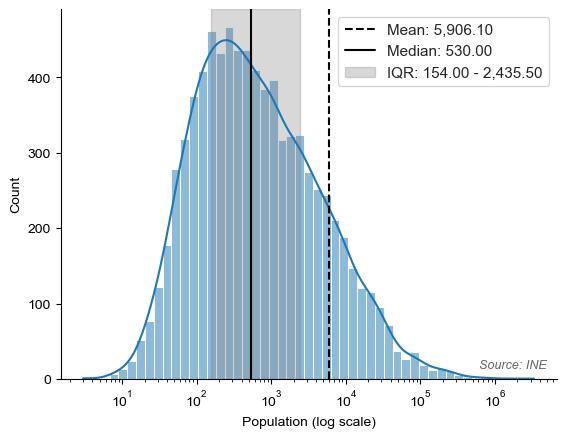

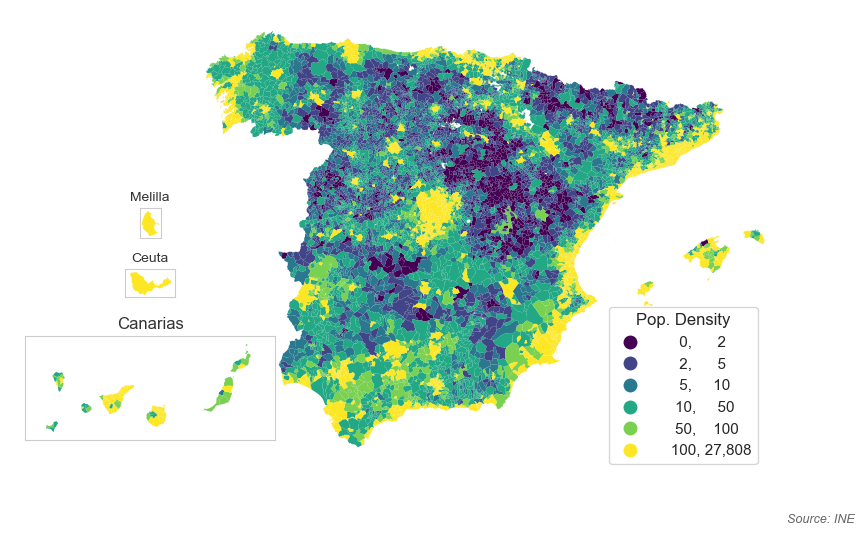

In [ ]:
plot, ax = plt.subplots(figsize=(6.4, 4.8))
plot_distribution(
        gdf[V_POPULATION_2023], 
        source_text='Source: INE',
        xlabel='Population (log scale)', 
        scale='log',
        ax=ax
)
plot.savefig('02_images/02_distribution_population.png', bbox_inches='tight', dpi=300)

plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf, 
    variable=V_DENSITY, 
    bins=[2, 5, 10, 50, 100], 
    cmap='viridis',
    legend_title='Pop. Density',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_population.png', bbox_inches='tight', dpi=300)


In [ ]:
gdf[gdf[V_POPULATION_2023] >= 10000].count()

objectid                771
natcode                 771
nombre                  771
cod_nut1                771
cod_nut2                771
cod_nut3                771
codmun_ine              771
ccaa                    771
cod_ccaa                771
cod_pro                 771
provincia               771
pob_npmun               771
pob_23                  771
dens_pob                771
edad_media              771
afi_1000                771
paro_1000               771
porc_pob65              771
pob_esup16              771
porc_pob_e              771
rat_mascul              771
rta_nt_med              771
pob_14                  771
pob_14_23               771
centroid_x              771
centroid_y              771
Votos válidos_2023      771
PSOE_2023               771
VOX_2023                771
SUMAR_2023              771
PP_2023                 771
Votos válidos_2019      771
PSOE_2019               771
VOX_2019                771
PP_2019                 771
SUMAR_2019          

In [ ]:
gdf[gdf[V_POPULATION_2023] >= 10000].sum(numeric_only=True)

objectid                3,352,359.00
pob_npmun                  29,981.73
pob_23                 38,435,514.00
dens_pob                1,021,601.65
edad_media                 33,437.16
afi_1000                  394,357.33
paro_1000                  67,994.81
porc_pob65                 14,265.49
pob_esup16                 22,149.69
porc_pob_e                  8,979.17
rat_mascul                 75,335.85
rta_nt_med             24,312,677.00
pob_14                 37,163,623.00
pob_14_23                   3,363.56
centroid_x                 -2,460.05
centroid_y                 30,418.69
Votos válidos_2023     19,164,715.00
PSOE_2023                  24,480.86
VOX_2023                    9,930.16
SUMAR_2023                  9,111.96
PP_2023                    24,393.06
Votos válidos_2019     19,012,436.00
PSOE_2019                  21,356.49
VOX_2019                   12,257.70
PP_2019                    15,381.94
SUMAR_2019                 11,613.04
PP_diff_2023_2019           9,011.11
P

As we can see from the histogram, the population distribution is right-skewed, indicating that there are many municipalities with small populations and a few with larger populations. The mean population is around 5,900 while the median is around 500 and even the third quartile is around 2,500, still much lower than the mean, which confirms the extreme skewness of the distribution. Therefore, 75% of the municipalities have a population of less than 2,500, while we can find a few large cities with populations exceeding 100,000, and even Madrid and Barcelona with a population of 3 million and 1.6 million respectively. Consequently, the huge number of small municipalities in Spain may distort the analysis when compared with the agregate data. Also, the presence of large cities like Madrid and Barcelona may also distort the analysis, as they are outliers in terms of population size.

### Population change between 2014 and 2023
The population change variable allows us to analyze how the population has changed between 2019 and 2023. We can analyze its distribution to understand the trends in population growth or decline across municipalities in Spain.

--- Summary Statistics: Population Change (%) ---


,count,mean,std,min,25%,50%,75%,max
pob_14_23,"8,131.00",-3.68,14.26,-67.75,-12.63,-4.19,4.22,150.00


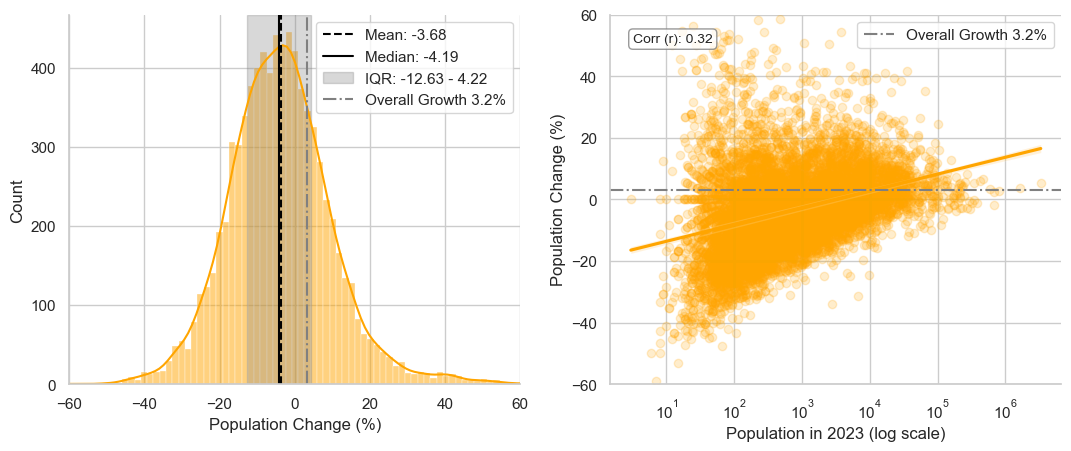

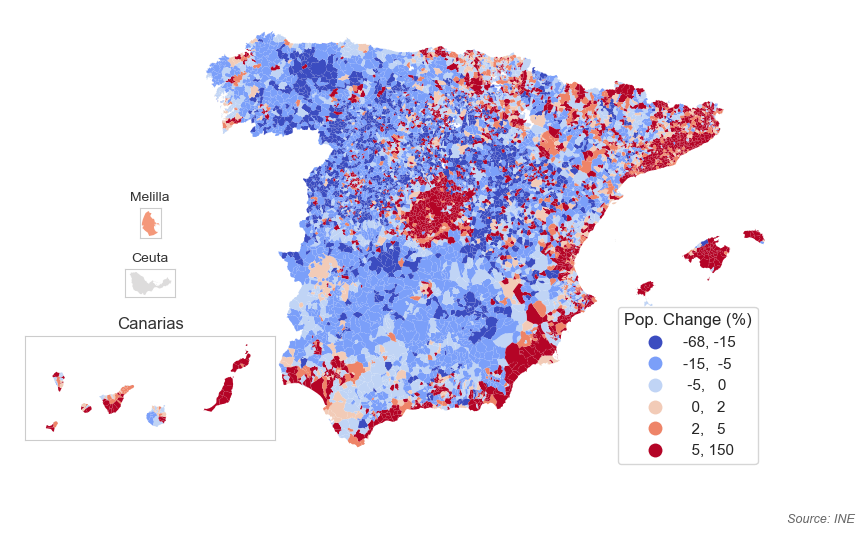

In [ ]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_POPULATION_CHANGE],
        xlabel='Population Change (%)',
        color='orange',
        limits=(-60, 60),
        ax=axes[0]
)
axes[0].axvline(3.2, color='grey', linestyle='-.', label=f'Overall Growth {3.2:,.1f}%')
axes[0].legend()
plot_scatter(
        data=gdf,
        x=V_POPULATION_2023,
        y=V_POPULATION_CHANGE,
        xlabel='Population in 2023 (log scale)',
        ylabel='Population Change (%)',
        color='orange',
        xscale='log',
        ylim=(-60, 60),
        ax=axes[1]
)
axes[1].axhline(3.2, color='grey', linestyle='-.', label=f'Overall Growth {3.2:,.1f}%')
axes[1].legend()
# plot.savefig('02_images/02_distribution_population_change.png', bbox_inches='tight', dpi=300)

plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf, 
    variable=V_POPULATION_CHANGE, 
    bins=[-15, -5, 0, 2, 5], 
    cmap='coolwarm',
    legend_title='Pop. Change (%)',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_population_change.png', bbox_inches='tight', dpi=300)

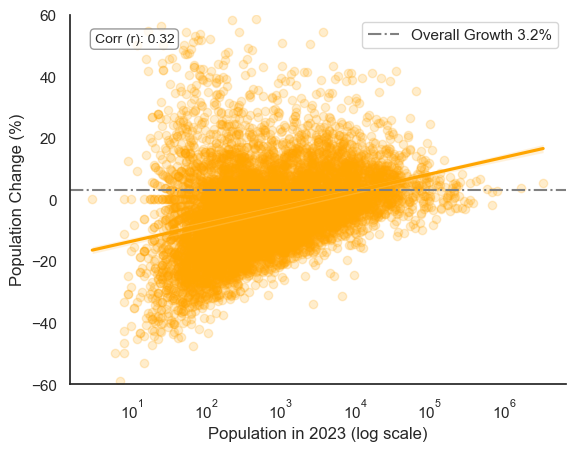

In [ ]:
plot, ax = plt.subplots(figsize=(6.4, 4.8))
plot_scatter(
        data=gdf,
        x=V_POPULATION_2023,
        y=V_POPULATION_CHANGE,
        xlabel='Population in 2023 (log scale)',
        ylabel='Population Change (%)',
        color='orange',
        xscale='log',
        ylim=(-60, 60),
        ax=ax
)
ax.axhline(3.2, color='grey', linestyle='-.', label=f'Overall Growth {3.2:,.1f}%')
ax.legend()
plot.savefig('02_images/02_distribution_population_change.png', bbox_inches='tight', dpi=300)

From 2014 to 2023, the total population in Spain increased from 46.5 million to 48 million, which represents a growth of around 3.2%. However, this growth is not uniform across all municipalities. Municipalities with smaller populations tend to be rural and have older populations, making them less attractive for inmigration, which leads to population decline due to outmigration and low birth rates. As the distribution of the population is dramatically skewed, as discussed before, the average municipality experienced a population decline of around 3.68%.

### Mean age
The mean age variable is an important demographic when analyzing electoral behavior, as it can influence voting patterns. We can analyze its distribution to understand the age demographics of the municipalities in Spain.

--- Summary Statistics: Mean Age (years) ---


,count,mean,std,min,25%,50%,75%,max
edad_media,"8,131.00",50.51,6.63,34.66,45.12,49.80,55.41,75.12


--- Summary Statistics: Population over 65 (%) ---


,count,mean,std,min,25%,50%,75%,max
porc_pob65,"8,131.00",29.41,10.94,5.27,20.87,27.96,36.67,80.00


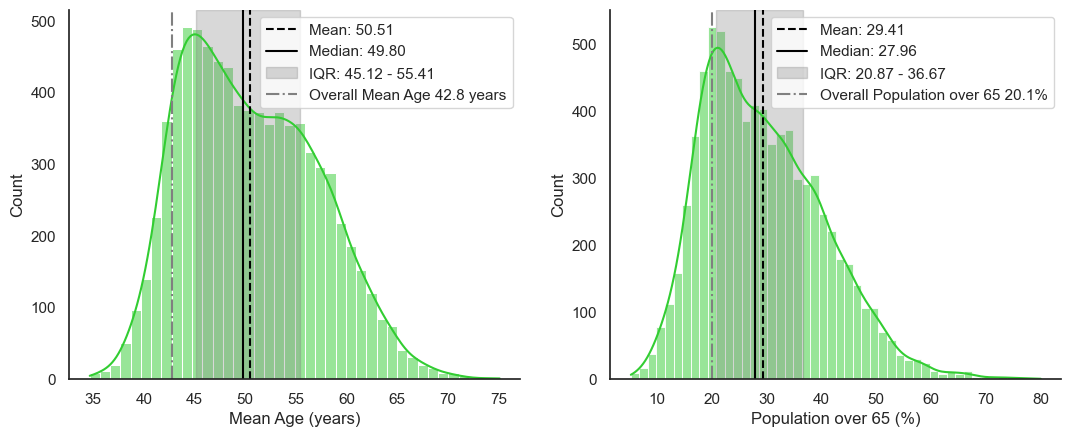

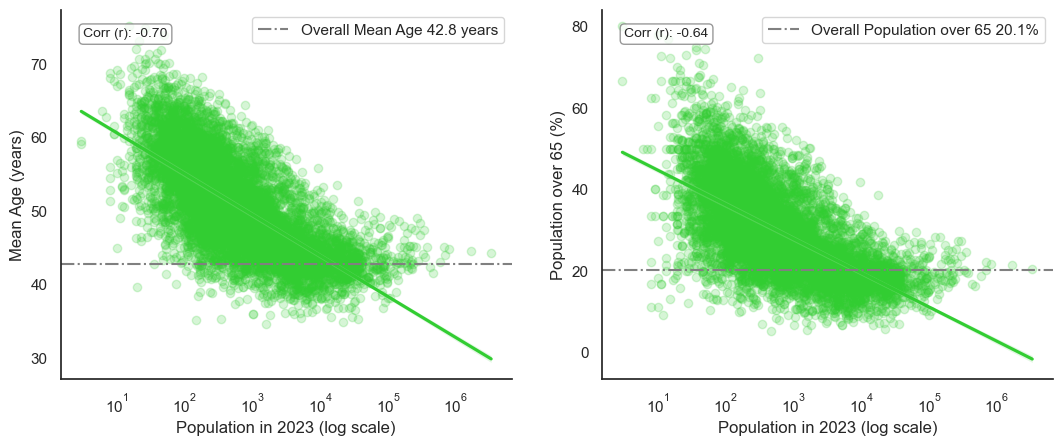

In [ ]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_MEAN_AGE],
        xlabel='Mean Age (years)',
        color='limegreen',
        scale='linear',
        ax=axes[0]
)
axes[0].axvline(42.8, color='grey', linestyle='-.', label=f'Overall Mean Age {42.8:.1f} years')
axes[0].legend()
plot_distribution(
        gdf[V_Population_over_65],
        xlabel='Population over 65 (%)',
        color='limegreen',
        scale='linear',
        ax=axes[1]
)
axes[1].axvline(20.15, color='grey', linestyle='-.', label=f'Overall Population over 65 {20.15:.1f}%')
axes[1].legend()
plot.savefig('02_images/02_distribution_age.png', bbox_inches='tight', dpi=300)

plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_Mean_age,
        xlabel='Population in 2023 (log scale)',
        ylabel='Mean Age (years)',
        xscale='log',
        color='limegreen',
        ax=axes[0]
)
axes[0].axhline(42.8, color='grey', linestyle='-.', label=f'Overall Mean Age {42.8:.1f} years')
axes[0].legend()
plot_scatter(
        data=gdf,
        x=V_POPULATION_2023,
        y=V_Population_over_65,
        xlabel='Population in 2023 (log scale)',
        ylabel='Population over 65 (%)',
        xscale='log',
        color='limegreen',
        ax=axes[1]
)
axes[1].axhline(20.15, color='grey', linestyle='-.', label=f'Overall Population over 65 {20.15:.1f}%')
axes[1].legend()
plot.savefig('02_images/02_scatter_age.png', bbox_inches='tight', dpi=300)

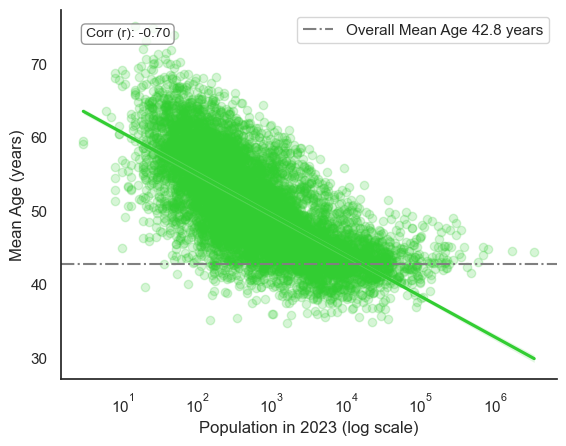

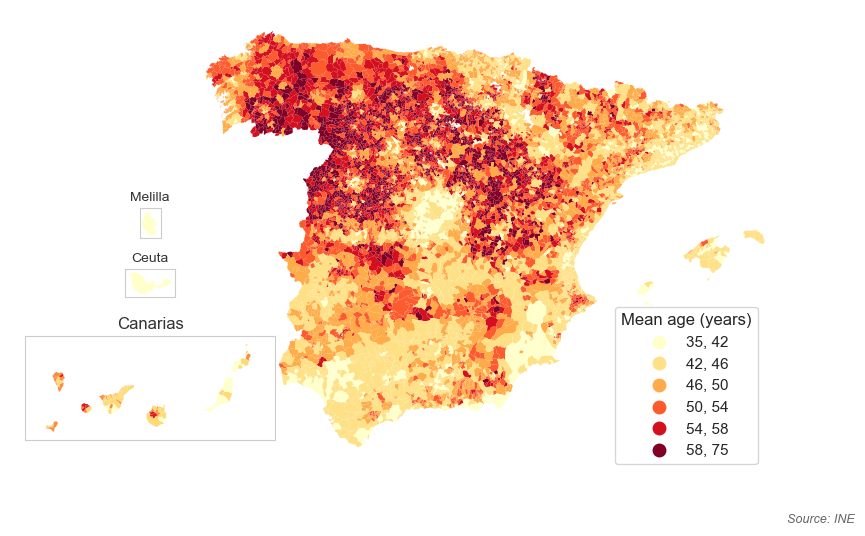

In [ ]:
plot, ax = plt.subplots(figsize=(6.4, 4.8))
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_Mean_age,
        xlabel='Population in 2023 (log scale)',
        ylabel='Mean Age (years)',
        xscale='log',
        color='limegreen',
        ax=ax
)
ax.axhline(42.8, color='grey', linestyle='-.', label=f'Overall Mean Age {42.8:.1f} years')
ax.legend()
plot.savefig('02_images/02_scatter_population_vs_age.png', bbox_inches='tight', dpi=300)

plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf, 
    variable=V_MEAN_AGE, 
    bins=[42, 46, 50, 54, 58], 
    cmap='YlOrRd', 
    legend_title='Mean age (years)',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_age.png', bbox_inches='tight', dpi=300)

As in the previous example, the distributions of the mean age and the % of the population over 65 are distorted by the skewed population distribution. In 2023, Spain had an average age of about 43 years, with 20% of the population being over 65 years old. However, both global figures are, again, below the first quartile of the distributions. The average municipality has a mean age of 50 years and 30% of its population is over 65 years old.

### Foreign Population
The percentage of foreign population in a municipality can also influence electoral behavior, as it may be associated with different political preferences and voting patterns.

--- Summary Statistics: Foreign Population (%) ---


,count,mean,std,min,25%,50%,75%,max
porc_pob_e,"8,131.00",7.24,7.62,0.00,2.11,4.96,10.09,88.61


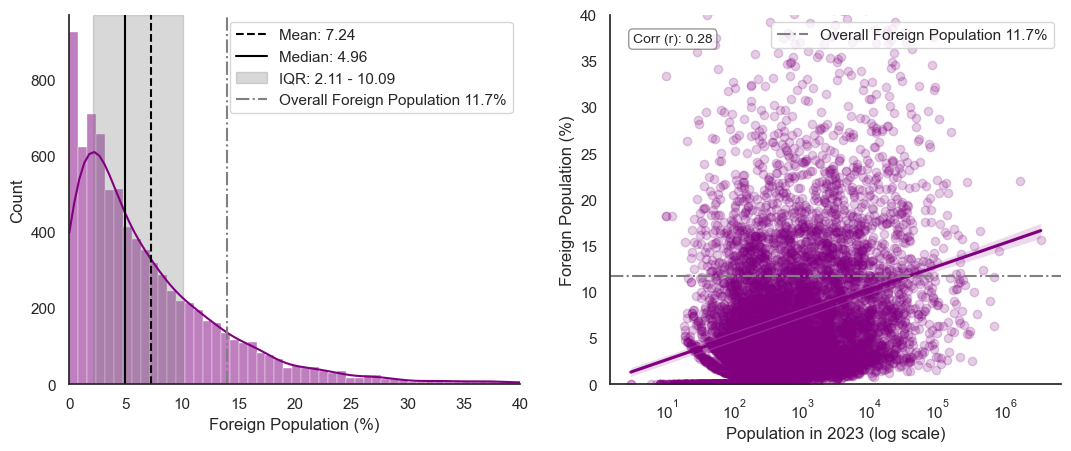

In [ ]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_FOREIGN_POPULATION],
        xlabel='Foreign Population (%)',
        color='purple',
        limits=(0, 40),
        ax=axes[0]
)
axes[0].axvline(14.0, color='grey', linestyle='-.', label=f'Overall Foreign Population {11.7:.1f}%')
axes[0].legend()
plot_scatter(
        data=gdf,
        x=V_Population_2023,
        y=V_FOREIGN_POPULATION,
        xlabel='Population in 2023 (log scale)',
        ylabel='Foreign Population (%)',
        color='purple',
        xscale='log',
        ylim=(0, 40),
        ax=axes[1]
)
axes[1].axhline(11.7, color='grey', linestyle='-.', label=f'Overall Foreign Population {11.7:.1f}%')
axes[1].legend()
plot.savefig('02_images/02_distribution_foreign.png', bbox_inches='tight', dpi=300)

Again, as in the previous examples, the smaller municipalities, which tend to be rural and have small foreign populations, distort the distribution. Despite having a 12% of foreign population in Spain, half of the municipalities have a foreign population of less than 5%. The scatter plot shows that there are some municipalities, most of them with populations below 1000, that have no foreign population at all.

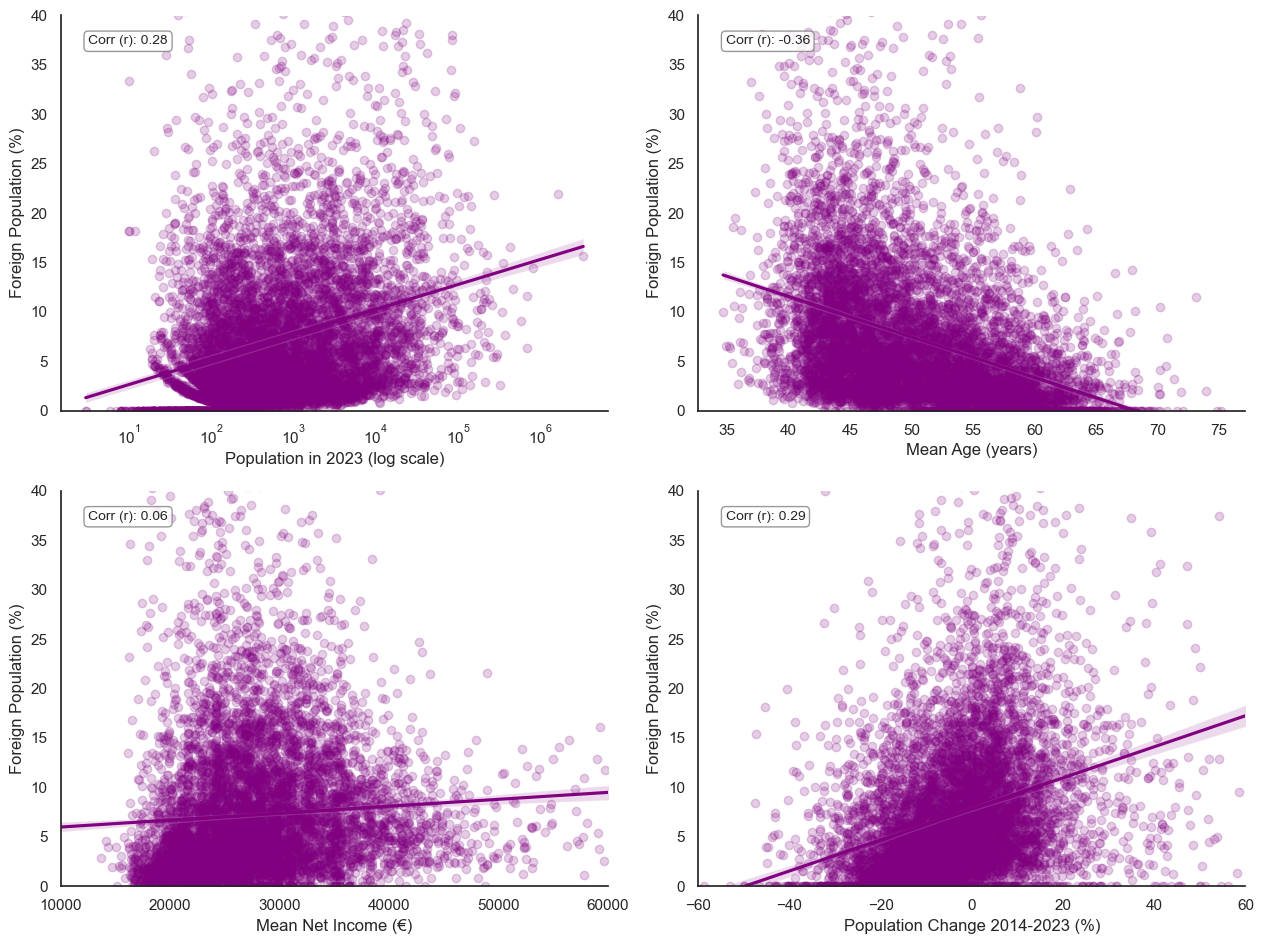

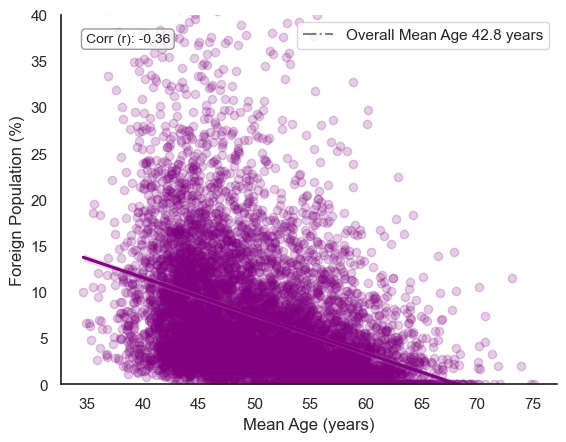

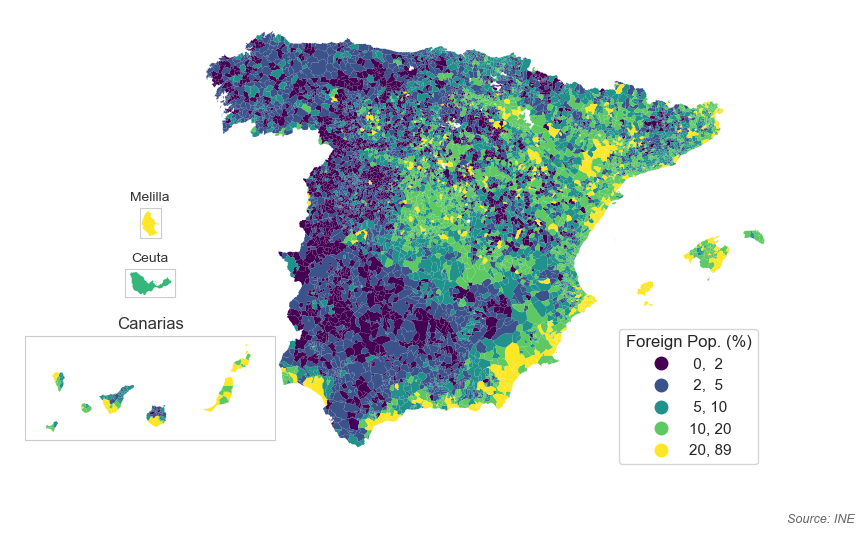

In [ ]:
plot, axes = plt.subplots(2, 2, figsize=(12.8, 9.6))
axes = axes.flatten()

# Scatter plot 1: Immigration vs Population
plot_scatter(
    data=gdf,
    x=V_POPULATION_2023,
    y=V_FOREIGN_POPULATION,
    xlabel='Population in 2023 (log scale)',
    ylabel='Foreign Population (%)',
    color='purple',
    xscale='log',
    ylim=(0, 40),
    ax=axes[0]
)

# Scatter plot 2: Immigration vs Mean Age
plot_scatter(
    data=gdf,
    x=V_Mean_age,
    y=V_Foreign_population,
    xlabel='Mean Age (years)',
    ylabel='Foreign Population (%)',
    color='purple',
    ylim=(0, 40),
    ax=axes[1]
)

# Scatter plot 3: Immigration vs Mean Income
plot_scatter(
    data=gdf,
    x=V_MEAN_NET_INCOME,
    y=V_FOREIGN_POPULATION,
    xlabel='Mean Net Income (€)',
    ylabel='Foreign Population (%)',
    color='purple',
    xlim=(10000, 60000),
    ylim=(0, 40),
    ax=axes[2]
)

# Scatter plot 4: Immigration vs Population Growth
plot_scatter(
    data=gdf,
    x=V_POPULATION_CHANGE,
    y=V_FOREIGN_POPULATION,
    xlabel='Population Change 2014-2023 (%)',
    ylabel='Foreign Population (%)',
    color='purple',
    xlim=(-60, 60),
    ylim=(0, 40),
    ax=axes[3]
)

plot.tight_layout()
#plot.savefig('02_images/04_scatter_immigration_analysis.png', bbox_inches='tight', dpi=300)
plt.show()


plot, ax = plt.subplots(figsize=(6.4, 4.8))
plot_scatter(
    data=gdf,
    x=V_Mean_age,
    y=V_Foreign_population,
    xlabel='Mean Age (years)',
    ylabel='Foreign Population (%)',
    color='purple',
    ylim=(0, 40),
    ax=ax
)
ax.axhline(42.8, color='grey', linestyle='-.', label=f'Overall Mean Age {42.8:.1f} years')
ax.legend()
plot.savefig('02_images/02_scatter_immigration_vs_age.png', bbox_inches='tight', dpi=300)

# Map of Spain depicting Foreign Population
plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf,
    variable=V_FOREIGN_POPULATION,
    bins=[2, 5, 10, 20],
    cmap='viridis',
    legend_title='Foreign Pop. (%)',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_foreign_population.png', bbox_inches='tight', dpi=300)
plt.show()


### Mean net income
The mean net income variable can provide insights into the economic status of the municipalities, which can also influence electoral behavior. Generally, income is positively correlated with the higher education level. 

--- Summary Statistics: Mean Net Income (€) ---


,count,mean,std,min,25%,50%,75%,max
rta_nt_med,"8,131.00","27,933.75","6,594.91",0.00,"23,277.00","27,074.00","30,992.00","83,377.00"


--- Summary Statistics: Population over 16 with Higher Education ---


,count,mean,std,min,25%,50%,75%,max
pob_esup16,"8,131.00",22.83,10.97,0.00,16.28,22.07,29.34,63.41


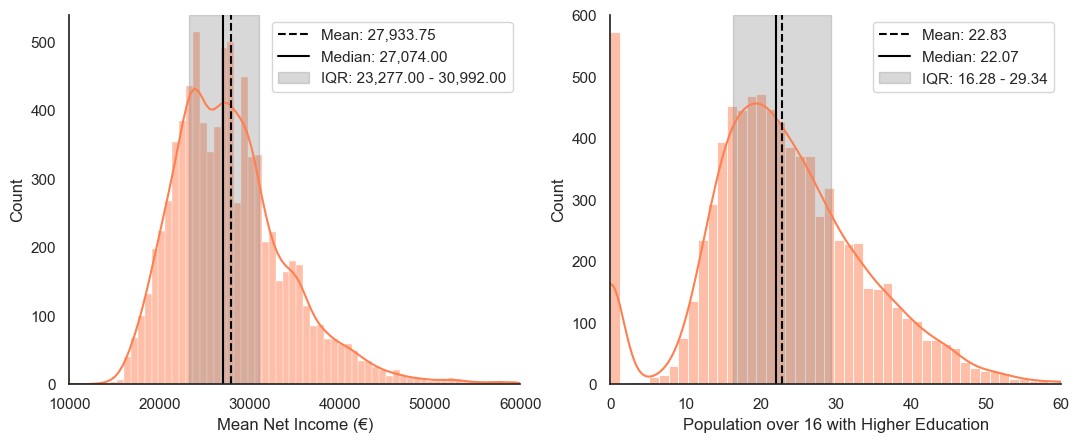

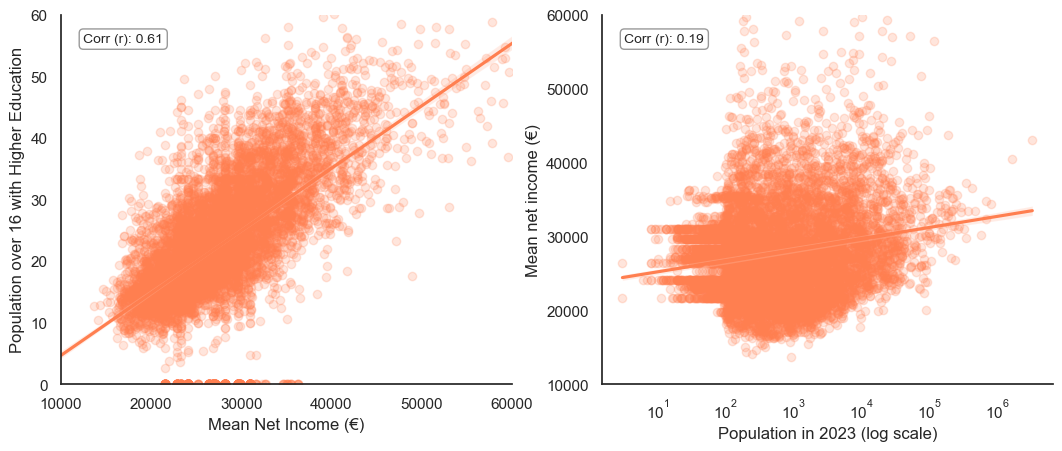

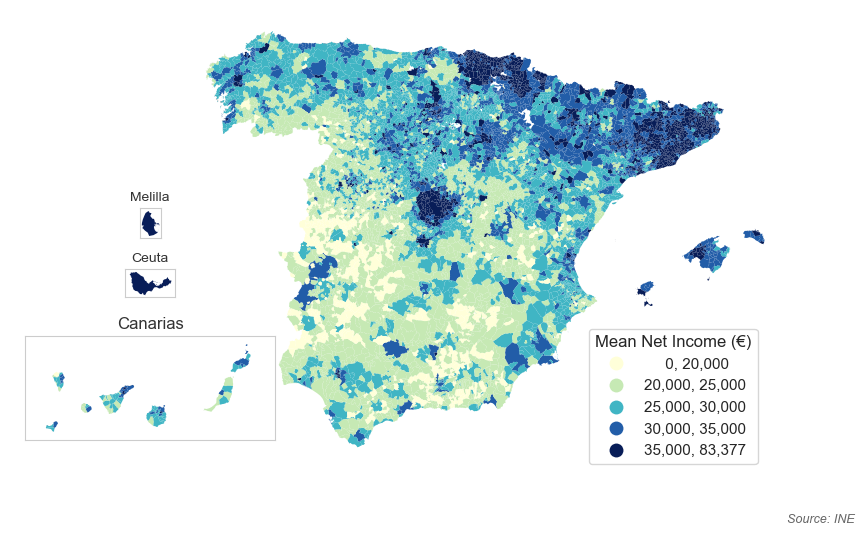

In [ ]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_MEAN_NET_INCOME],
        xlabel='Mean Net Income (€)',
        color='coral',
        limits=(10000, 60000),
        ax=axes[0]
)
plot_distribution(
        gdf[V_HIGHER_EDUCATION],
        xlabel='Population over 16 with Higher Education',
        color='coral',
        limits=(0, 60),
        ax=axes[1]
)
plot.savefig('02_images/02_distribution_income.png', bbox_inches='tight', dpi=300)

plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_scatter(
        data=gdf,
        x=V_MEAN_NET_INCOME,
        y=V_HIGHER_EDUCATION,
        xlabel='Mean Net Income (€)',
        ylabel='Population over 16 with Higher Education',
        color='coral',
        xlim=(10000, 60000),
        ylim=(0, 60),
        ax=axes[0]
)
plot_scatter(
        data=gdf,
        x=V_POPULATION_2023,
        y=V_MEAN_NET_INCOME,
        xlabel='Population in 2023 (log scale)',
        ylabel='Mean net income (€)',
        xscale='log',
        color='coral',
        ylim=(10000, 60000),
        ax=axes[1]
)
plot.savefig('02_images/02_scatter_income.png', bbox_inches='tight', dpi=300)

plot, ax = plt.subplots(figsize=(10, 6))
plot_spanish_map(
    gdf, 
    variable=V_MEAN_NET_INCOME, 
    bins=[20000, 25000, 30000, 35000], 
    cmap='YlGnBu', 
    legend_title='Mean Net Income (€)',
    source_text='Source: INE',
    ax=ax
)
plot.savefig('02_images/02_map_income.png', bbox_inches='tight', dpi=300)

As we can see in the second scatter plot, there is a positive correlation between mean net income and population size, which is expected as larger cities tend to have higher incomes due to scale economies. On the other hand, there is also a strong correlation between the mean net income and the population over 16 with higher education, which is also expected as higher education levels are often associated with higher income levels. About the distribution of the mean net income, it is also right-skewed, showing a long tail of municipalities with higher incomes, which reflects some inequality in the distribution of income.

It is interesting to note the presence of municipalities without population with higher education. Those are generally municipalities with very small and old populations in rural areas.

### Workforce affiliation and unemployment
The workforce affiliation and unemployment variables can provide insights into the economic activity and labor market conditions in the municipalities, which can also influence electoral behavior. Generally, higher workforce affiliation and lower unemployment rates are associated with better economic conditions and may influence voting patterns.

--- Summary Statistics: Workforce Affiliation per 1000 Inhabitants ---


,count,mean,std,min,25%,50%,75%,max
afi_1000,"8,131.00",443.71,343.99,0.00,279.29,381.35,507.09,"7,293.24"


--- Summary Statistics: Unemployment per 1000 Inhabitants ---


,count,mean,std,min,25%,50%,75%,max
paro_1000,"8,131.00",69.12,42.94,0.00,40.28,64.73,92.08,"1,000.00"


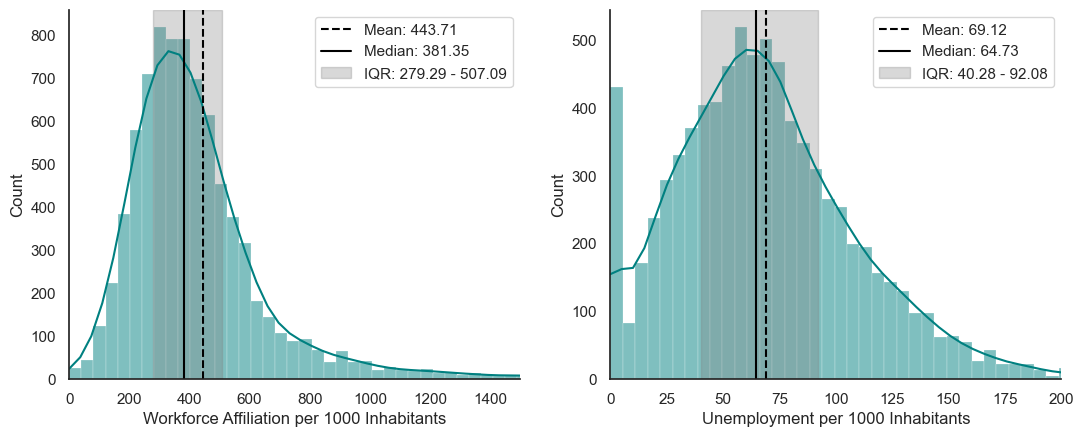

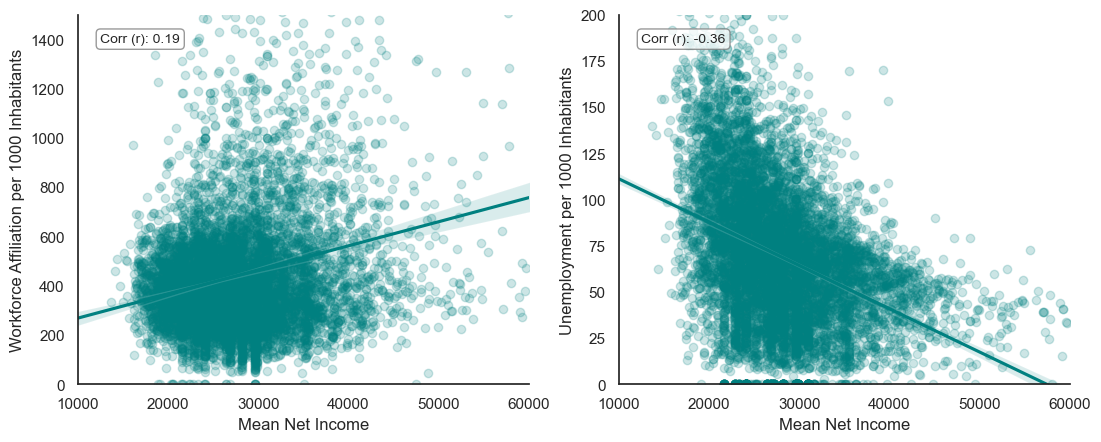

In [ ]:
plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_distribution(
        gdf[V_AFFILIATION],
        xlabel='Workforce Affiliation per 1000 Inhabitants',
        color='teal',
        limits=(0, 1500),
        ax=axes[0]
)
plot_distribution(
        gdf[V_UNEMPLOYMENT],
        xlabel='Unemployment per 1000 Inhabitants',
        color='teal',
        limits=(0, 200),
        ax=axes[1]
)
plot.savefig('02_images/02_distribution_workforce.png', bbox_inches='tight', dpi=300)

plot, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
plot_scatter(
        data=gdf,
        x=V_MEAN_NET_INCOME,
        y=V_AFFILIATION,
        xlabel='Mean Net Income',
        ylabel='Workforce Affiliation per 1000 Inhabitants',
        color='teal',
        xlim=(10000, 60000),
        ylim=(0, 1500),
        ax=axes[0]
)
plot_scatter(
        data=gdf,
        x=V_MEAN_NET_INCOME,
        y=V_UNEMPLOYMENT,
        xlabel='Mean Net Income',
        ylabel='Unemployment per 1000 Inhabitants',
        color='teal',
        xlim=(10000, 60000),
        ylim=(0, 200),
        ax=axes[1]
)
plot.savefig('02_images/02_scatter_workforce.png', bbox_inches='tight', dpi=300)

As we could expect, there is a positive correlation between workforce affiliation and mean net income, as well as a negative correlation between unemployment and mean net income. The distributions are again right-skewed. It is remarkable the existance of some outliers with unemployment rates of 0%. This may seem an indication of a very good economic condition, but it is a consequence of the small and old populations with little economic activity and a high percentage of retired people. It is also interesting to note the presence of some municipalities with workforce affiliation rates above 100%, which is due to the fact that a worker is counted in the municipality where he works, which may be different from the municipality where he lives. Therefore, municipalities with small populations and strong economic activity may have workforce affiliation rates above 1000. The muncipality in Spain with the highest workforce affiliation rate is Figueruelas, with a workforce affiliation rate of almos 7300 due to the presence of a large automotive factory of Stellantis and a small population of around 1250 people. Another example is the municipality of Zamundio, being the location of a science park with 300 companies and more than 11000 workers, while having a population of around 3300 people, which leads to a workforce affiliation rate of around 7200..

## Electoral Analysis
In this section, we analyse electoral variables.

In [38]:
def plot_boxplot(data, value_vars, id_vars=None, var_name='Party', value_name='Votes', 
                 palette=None, title=None, xlabel=None, ylabel=None, 
                 source_text=None, yscale='linear', ylim=None, ax=None,
                 actual_results=None, actual_marker='D', actual_size=80):
    """
    Melts a DataFrame and plots a boxplot to compare distributions across multiple categories,
    with an optional overlay for 'actual' results.
    
    Parameters:
    - data: The pandas DataFrame or GeoDataFrame containing the data.
    - value_vars: List of column names to plot (e.g., list of parties).
    - id_vars: Column name(s) to keep as identifiers during the melt (optional).
    - var_name: String, name for the melted variable column.
    - value_name: String, name for the melted value column.
    - palette: Dictionary or string for the seaborn color palette.
    - title: String for the chart title.
    - xlabel: String for the x-axis label.
    - ylabel: String for the y-axis label.
    - source_text: String for the source citation to display at the bottom right.
    - yscale: 'linear', 'log', or 'symlog' for the y-axis.
    - ylim: Tuple for y-axis limits (e.g., (0, 100)). None by default.
    - ax: Matplotlib axes object to plot on (for subplots). If None, creates a new one.
    - actual_results: Dictionary mapping categories in value_vars to their actual numeric value.
    - actual_marker: String, Matplotlib marker style ('D' for diamond, 'o' for circle, etc.).
    - actual_size: Integer, size of the actual result marker.
    """
    
    sns.set_theme(style="whitegrid")

    # 1. Melt the dataframe to long format required by Seaborn
    df_long = data.melt(
        id_vars=id_vars,
        value_vars=value_vars, 
        var_name=var_name, 
        value_name=value_name
    )

    # 2. Create an axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # 3. Create the boxplot
    sns.boxplot(
        data=df_long, 
        x=var_name, 
        y=value_name, 
        palette=palette,
        width=0.6,
        fliersize=3,      # Size of the outlier points
        linewidth=1.5,
        ax=ax
    )

    # 4. Overlay actual results if provided
    if actual_results is not None:
        for i, category in enumerate(value_vars):
            if category in actual_results:
                # Use the color from the palette if it's a dict, otherwise fallback to black
                dot_color = palette[category] if isinstance(palette, dict) and category in palette else 'black'
                
                ax.scatter(
                    x=i,                               # Categorical x-axis positions are exactly 0, 1, 2, 3...
                    y=actual_results[category],        # The actual value to plot
                    color=dot_color,                   # Color of the dot
                    marker=actual_marker,              # 'D' for Diamond by default
                    s=actual_size,                     # Size of the marker
                    zorder=10,                         # Forces the dot to render ON TOP of the boxes
                    edgecolor='white',                 # White outline so it pops
                    linewidth=1.5
                )

        # Add a custom legend entry for the actual result
        ax.scatter([], [], color='black', marker=actual_marker, edgecolor='white', label='Actual Result')
        ax.legend(loc='upper right')

    # 5. Apply axis scaling
    if yscale in ['log', 'symlog']:
        ax.set_yscale(yscale)
        
    # 6. Apply limits if provided
    if ylim:
        ax.set_ylim(ylim)

    # 7. Apply Labels and Title
    ax.set_xlabel(xlabel if xlabel else var_name, fontsize=12)
    ax.set_ylabel(ylabel if ylabel else value_name, fontsize=12)
    if title:
        ax.set_title(title, fontsize=15, fontweight='bold', pad=15)

    # 8. Add source text citation
    if source_text:
        ax.text(
            0.98, 0.02,              
            source_text, 
            transform=ax.transAxes, 
            ha='right',              
            va='bottom',             
            fontsize=9, 
            color='#666666',         
            style='italic'           
        )

    # 9. Clean up styling
    sns.despine(left=True) 
    
    # Optional: tight_layout is generally better applied at the Figure level
    if ax.figure is not None:
        ax.figure.tight_layout()

    return fig, ax

C:\Users\rodri\AppData\Local\Temp\ipykernel_23784\2621496805.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


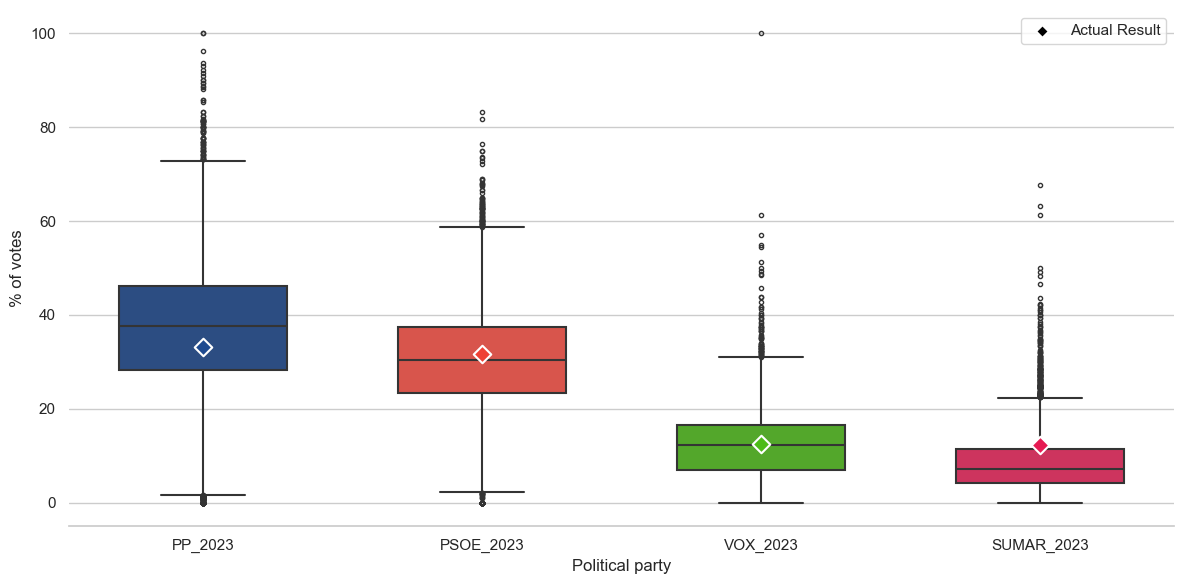

In [39]:
PARTIES_2023 = [V_PP_2023, V_PSOE_2023, V_VOX_2023, V_SUMAR_2023]

plot, ax = plot_boxplot(
    data=gdf,
    value_vars=PARTIES_2023,
    palette=COLOURS_PARTIES,
    xlabel='Political party',
    ylabel='% of votes',
    actual_results=ELECTORAL_RESULTS_2023
)

plot.savefig('02_images/02_boxplot_2023_parties.png', bbox_inches='tight', dpi=300)

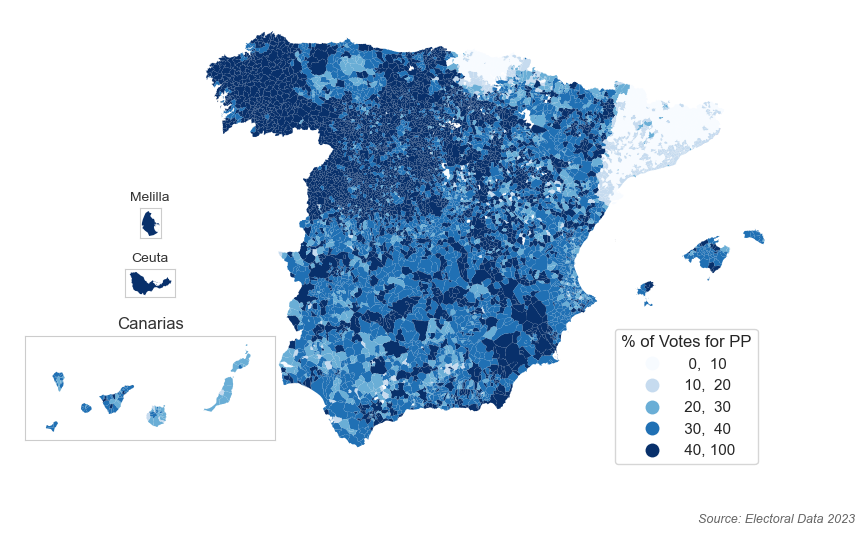

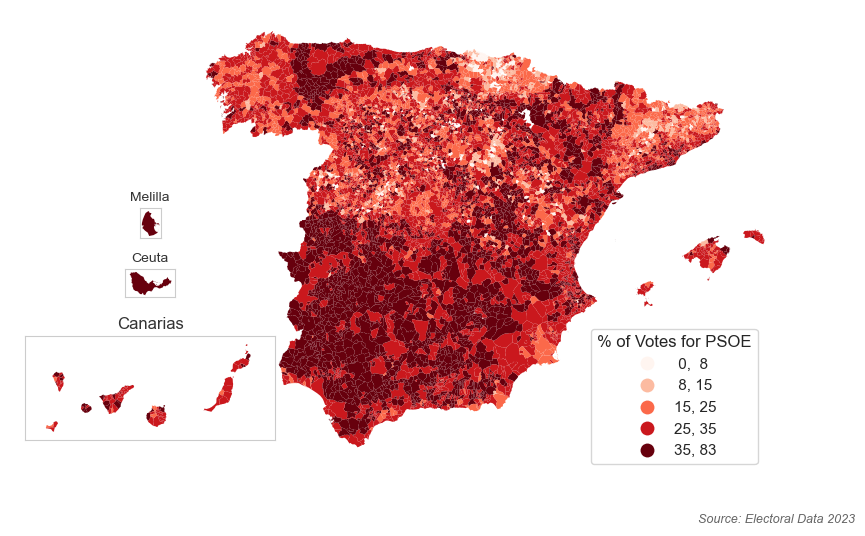

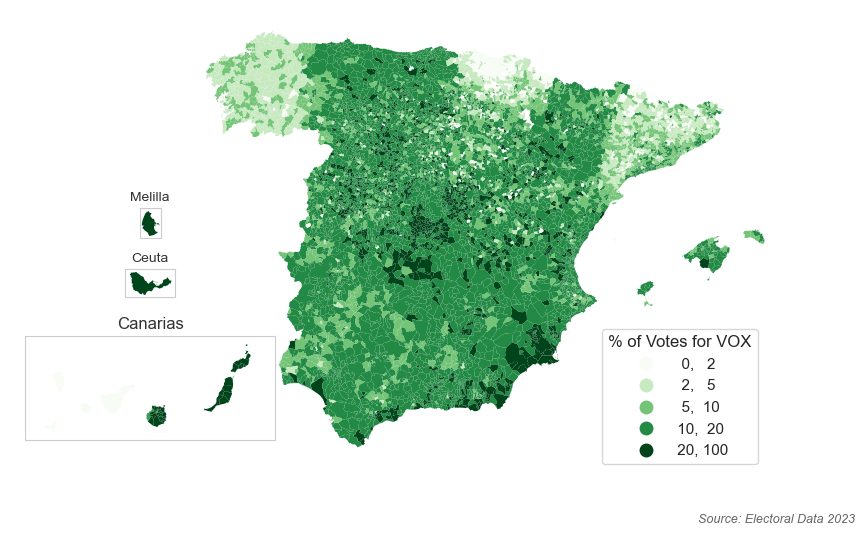

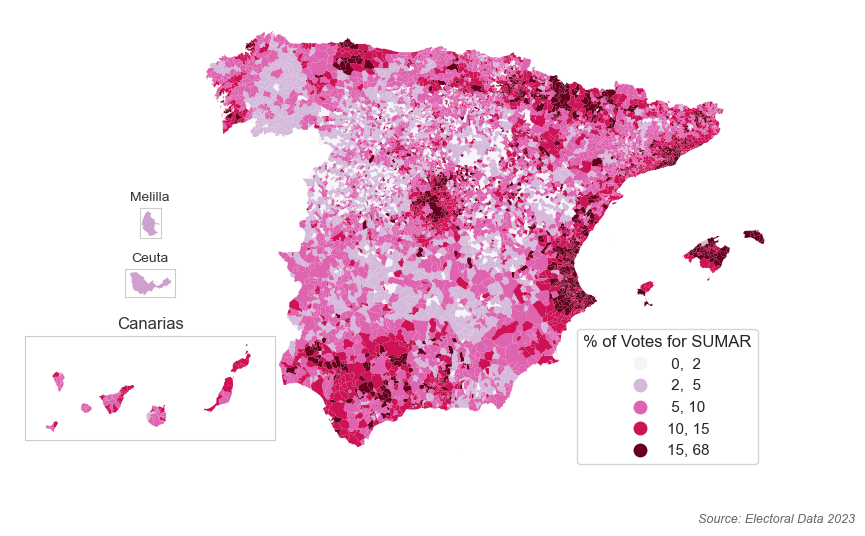

In [42]:
### Electoral Maps by Party (2023)
# Create four choropleth maps showing vote share distribution for each party

# Define the parties and their metadata
party_maps_config = [
    {
        'variable': V_PP_2023,
        'party_name': 'PP',
        'bins': [10, 20, 30, 40],
        'cmap': 'Blues',
        'filename': '02_images/02_map_PP_2023.png'
    },
    {
        'variable': V_PSOE_2023,
        'party_name': 'PSOE',
        'bins': [8, 15, 25, 35],
        'cmap': 'Reds',
        'filename': '02_images/02_map_PSOE_2023.png'
    },
    {
        'variable': V_VOX_2023,
        'party_name': 'VOX',
        'bins': [2, 5, 10, 20],
        'cmap': 'Greens',
        'filename': '02_images/02_map_VOX_2023.png'
    },
    {
        'variable': V_SUMAR_2023,
        'party_name': 'SUMAR',
        'bins': [2, 5, 10, 15],
        'cmap': 'PuRd',
        'filename': '02_images/02_map_SUMAR_2023.png'
    }
]

# Generate maps for each party
for config in party_maps_config:
    plot, ax = plt.subplots(figsize=(10, 6))
    plot_spanish_map(
        gdf,
        variable=config['variable'],
        bins=config['bins'],
        cmap=config['cmap'],
        legend_title=f'% of Votes for {config["party_name"]}',
        source_text='Source: Electoral Data 2023',
        ax=ax
    )
    plot.savefig(config['filename'], bbox_inches='tight', dpi=300)
    plt.show()


In [22]:
def plot_scatter_parties(
    data,
    parties,
    x_variable,
    region_column=None,
    regions_to_highlight=None,
    party_colors=COLOURS_PARTIES,
    figsize=(12.8, 9.6),
    alpha_highlighted=0.7,
    alpha_other=0.15,
    ylim_dict=None,
    xlim=None,
    xscale='linear',
    yscale='linear',
    trendline=True,
    show_corr=True,
    title=None,
    source_text=None
):
    """
    Creates a 2x2 grid of scatterplots for multiple parties with full flexibility.
    Combines region highlighting, custom y-limits, trendlines, and correlation display.
    
    Parameters:
    - data: The pandas DataFrame or GeoDataFrame containing the data.
    - parties: List of column names (party vote percentages) to plot.
    - x_variable: String, column name for the x-axis variable.
    - region_column: String, name of the column containing region assignments (optional).
                    If provided, enables region highlighting. If None, no region filtering.
    - regions_to_highlight: List of region names to highlight. 
                           If None or empty, all regions highlighted (or no filtering if region_column is None).
    - party_colors: Dictionary mapping party names to colors (default: COLOURS_PARTIES).
    - figsize: Tuple for figure size (width, height).
    - alpha_highlighted: Float (0 to 1) for alpha of highlighted regions (default: 0.7).
    - alpha_other: Float (0 to 1) for alpha of non-highlighted regions (default: 0.15).
    - ylim_dict: Dictionary mapping party names to y-axis limits tuples (e.g., {'PP_2023': (0, 60)}).
    - xlim: Tuple for x-axis limits (e.g., (0, 1000)). None by default. Applied to all subplots.
    - xscale: 'linear', 'log', or 'symlog' for the x-axis.
    - yscale: 'linear', 'log', or 'symlog' for the y-axis.
    - trendline: Boolean to include linear regression trendlines (default: True).
    - show_corr: Boolean to display Pearson correlation coefficients (default: True).
    - title: String for the main figure title (default: None, no title displayed).
    - source_text: String for the source citation to display at the bottom right.
    
    Returns:
    - fig: Matplotlib figure object
    - axes: 1D array of matplotlib axes objects
    """
    
    # Handle region column if provided
    region_col = None
    if region_column is not None:
        if isinstance(region_column, str):
            if region_column in data.columns:
                region_col = data[region_column]
            else:
                raise ValueError(f"Column '{region_column}' not found in data")
        else:
            region_col = region_column
    
    # Parse regions to highlight
    if regions_to_highlight is None:
        regions_to_highlight = []
    else:
        regions_to_highlight = list(regions_to_highlight)
    
    # Determine if we should highlight all regions (only when region_col exists)
    highlight_all = (region_col is not None) and (len(regions_to_highlight) == 0)
    use_regions = region_col is not None
    
    # Parse ylim_dict
    if ylim_dict is None:
        ylim_dict = {}
    
    # Create a copy with region column if needed
    data_copy = data.copy()
    if use_regions:
        data_copy['_region_'] = region_col
    
    # 1. Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    # 2. Loop through each party
    for i, party in enumerate(parties):
        ax = axes[i]
        
        # Extract party name
        party_name = party.split('_')[0]
        
        # Get party color
        party_color = party_colors.get(party, '#333333')
        
        # Get y-limits for this party if specified
        ylim = ylim_dict.get(party, None)
        
        if use_regions:
            if highlight_all:
                # If no regions selected, plot all in party color
                sns.scatterplot(
                    data=data_copy,
                    x=x_variable,
                    y=party,
                    color=party_color,
                    alpha=alpha_highlighted,
                    s=40,
                    edgecolor=None,
                    ax=ax
                )
            else:
                # If regions selected, plot non-highlighted in gray first
                sns.scatterplot(
                    data=data_copy,
                    x=x_variable,
                    y=party,
                    color='#cccccc',
                    alpha=alpha_other,
                    s=40,
                    edgecolor=None,
                    ax=ax,
                    label='Other Regions'
                )
                
                # Overlay highlighted regions with party color
                for region in regions_to_highlight:
                    region_data = data_copy[data_copy['_region_'] == region]
                    if not region_data.empty:
                        sns.scatterplot(
                            data=region_data,
                            x=x_variable,
                            y=party,
                            color=party_color,
                            alpha=alpha_highlighted,
                            s=40,
                            edgecolor=None,
                            ax=ax,
                            label=region
                        )
        else:
            # No region filtering, just plot all points
            sns.scatterplot(
                data=data_copy,
                x=x_variable,
                y=party,
                color=party_color,
                alpha=alpha_highlighted,
                s=40,
                edgecolor=None,
                ax=ax
            )
        
        # Determine which data to use for trendline and correlation
        if use_regions and not highlight_all:
            # Use only the highlighted regions' data
            trendline_data = data_copy[data_copy['_region_'].isin(regions_to_highlight)]
        else:
            # Use all data
            trendline_data = data_copy
        
        # Add trendline if requested
        if trendline:
            sns.regplot(
                data=trendline_data,
                x=x_variable,
                y=party,
                scatter=False,
                color=party_color,
                line_kws={'linewidth': 2, 'alpha': 0.7},
                ax=ax,
                logx=(xscale == 'log')
            )
        
        # Apply axis scaling
        if xscale in ['log', 'symlog']:
            ax.set_xscale(xscale)
        if yscale in ['log', 'symlog']:
            ax.set_yscale(yscale)
        
        # Apply x-limits if provided
        if xlim:
            ax.set_xlim(xlim)
        
        # Apply y-limits if provided
        if ylim:
            ax.set_ylim(ylim)
        
        # Compute and display correlation if requested
        if show_corr:
            clean_data = trendline_data[[x_variable, party]].dropna()
            if len(clean_data) > 0:
                # Calculate Pearson correlation based on scales
                if xscale == 'log' and yscale == 'log':
                    corr_val = np.log(clean_data[x_variable]).corr(np.log(clean_data[party]))
                elif xscale == 'log':
                    corr_val = np.log(clean_data[x_variable]).corr(clean_data[party])
                elif yscale == 'log':
                    corr_val = clean_data[x_variable].corr(np.log(clean_data[party]))
                else:
                    corr_val = clean_data[x_variable].corr(clean_data[party])
                
                # Create a text box for the correlation
                textstr = f'Corr (r): {corr_val:.2f}'
                props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
                
                # Place text in the top-left corner
                ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                        verticalalignment='top', bbox=props)
        
        # Labels and Title
        ax.set_xlabel(x_variable, fontsize=11)
        ax.set_ylabel(party, fontsize=11)
        ax.set_title(f'{party_name} Vote Share', fontsize=12, fontweight='bold')
        
        # Show legend only when specific regions are highlighted
        if use_regions and not highlight_all and len(regions_to_highlight) > 0:
            ax.legend(loc='upper right', fontsize=9)
        
        sns.despine()
    
    # 3. Add main title
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    
    # 4. Add source text if provided
    if source_text:
        fig.text(
            0.98, 0.02,
            source_text,
            ha='right',
            va='bottom',
            fontsize=9,
            color='#666666',
            style='italic'
        )
    
    plt.tight_layout()
    
    return fig, axes



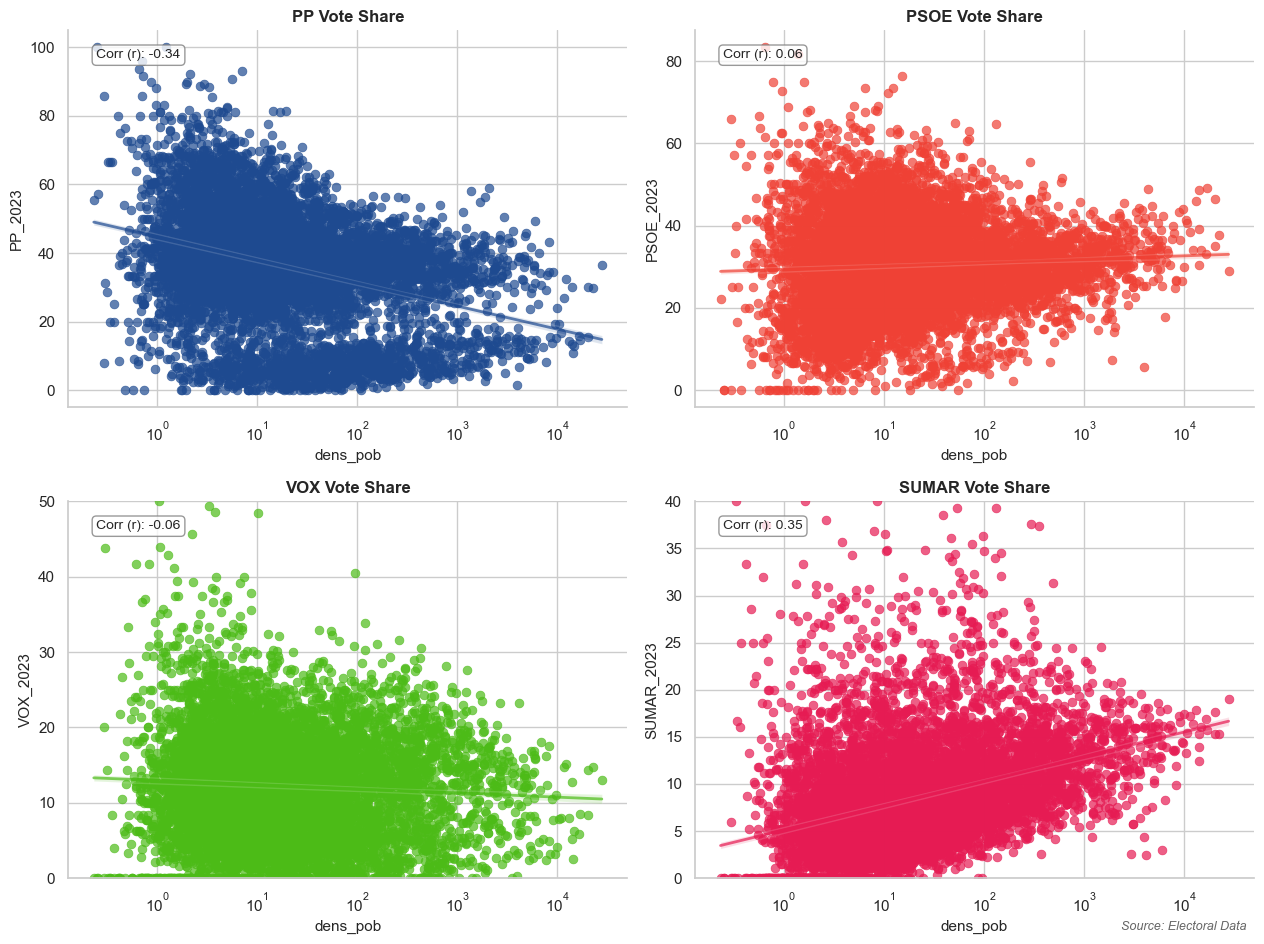

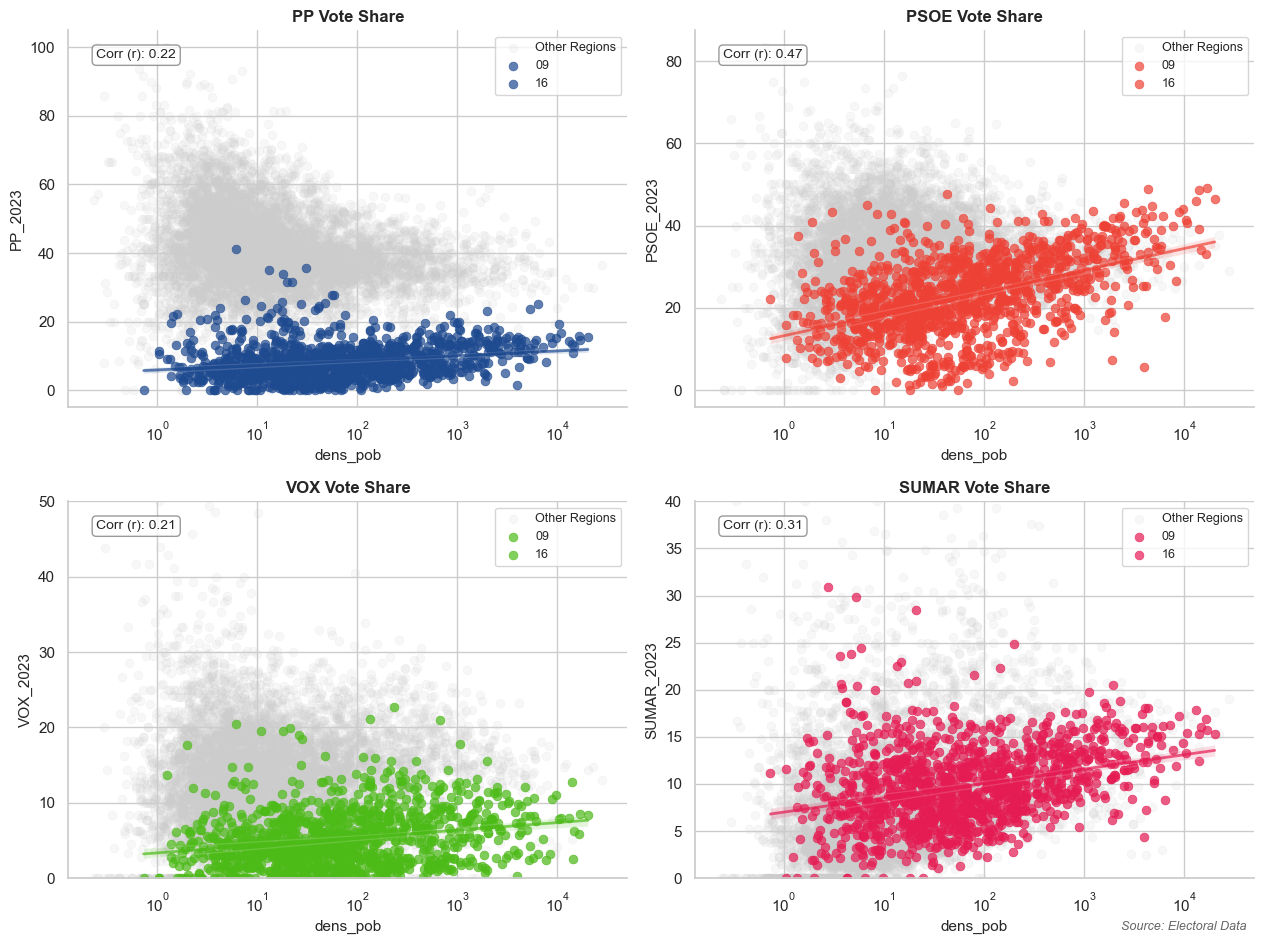

In [ ]:

plot, axes = plot_scatter_parties(
    data=gdf,
    x_variable=V_DENSITY,
    parties=[V_PP_2023, V_PSOE_2023, V_VOX_2023, V_SUMAR_2023],
    xscale='log',
    ylim_dict={V_VOX_2023: (0, 50), V_SUMAR_2023: (0, 40)},
    trendline=True,
    show_corr=True,
    source_text='Source: Electoral Data'
)
plot.savefig('02_images/02_scatter_2023_density_.png', bbox_inches='tight', dpi=300)

# With region highlighting and custom limits
plot, axes = plot_scatter_parties(
    data=gdf,
    x_variable=V_DENSITY,
    parties=[V_PP_2023, V_PSOE_2023, V_VOX_2023, V_SUMAR_2023],
    region_column=V_CCAA,
    regions_to_highlight=[C_CCAA_CATALUNYA, C_CCAA_PAIS_VASCO],
    xscale='log',
    ylim_dict={V_VOX_2023: (0, 50), V_SUMAR_2023: (0, 40)},
    trendline=True,
    show_corr=True,
    source_text='Source: Electoral Data'
)
plot.savefig('02_images/02_scatter_2023_density_highlighted.png', bbox_inches='tight', dpi=300)

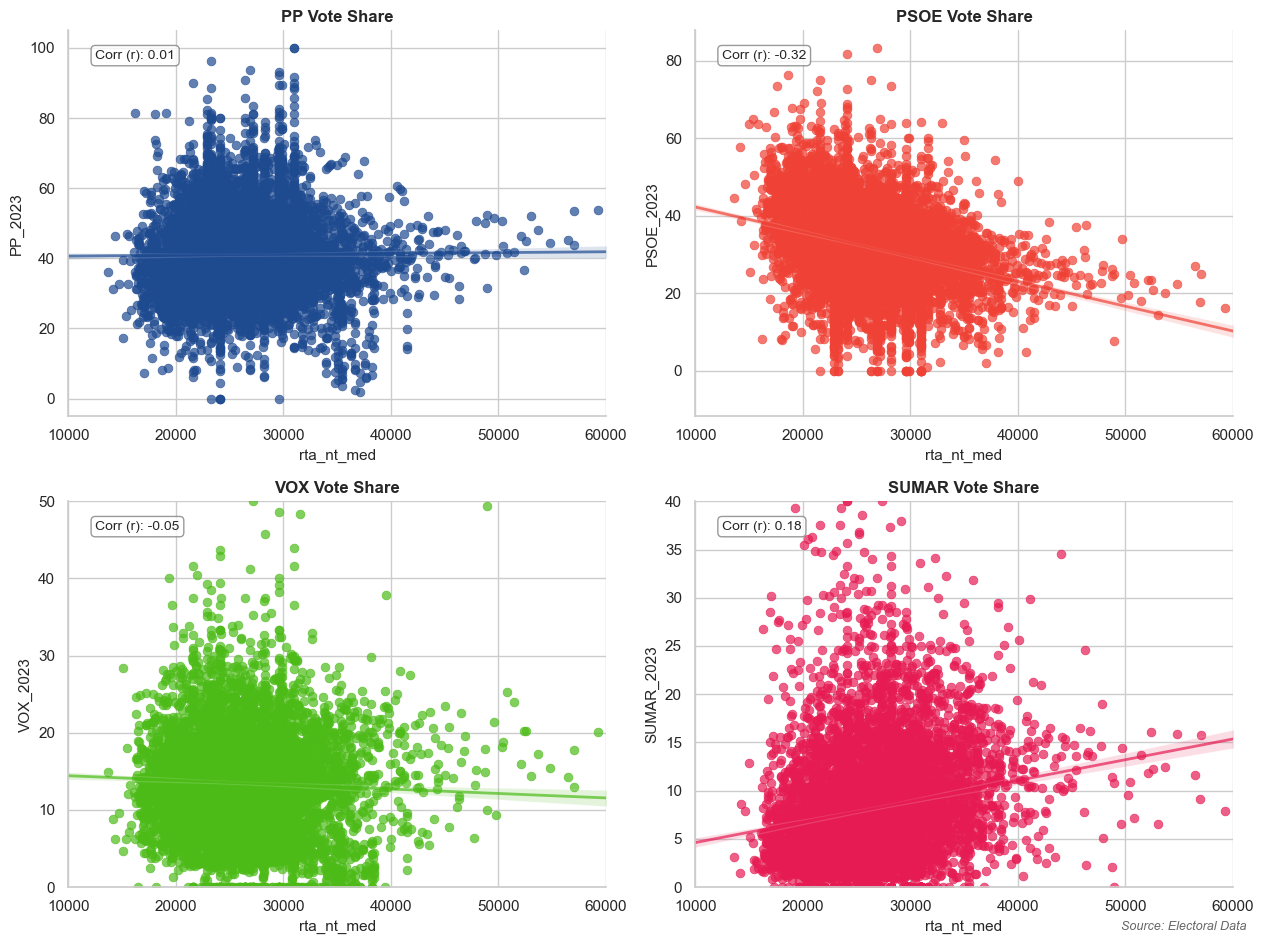

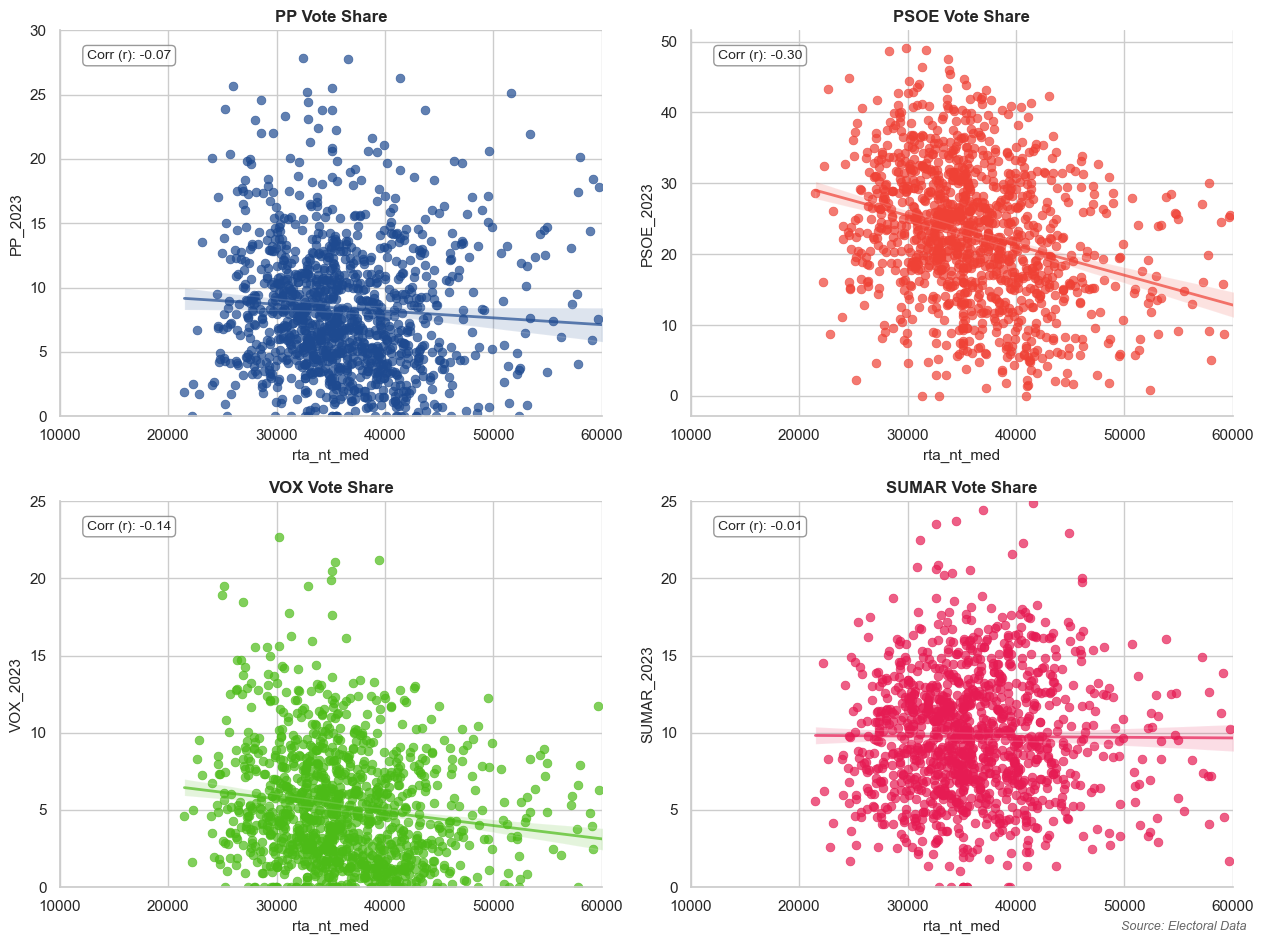

In [44]:
plot, axes = plot_scatter_parties(
    data=gdf[~gdf[V_CCAA].isin([C_CCAA_CATALUNYA, C_CCAA_PAIS_VASCO])].copy(),
    x_variable=V_Mean_net_income,
    parties=[V_PP_2023, V_PSOE_2023, V_VOX_2023, V_SUMAR_2023],
    xlim=(10000, 60000),
    ylim_dict={V_VOX_2023: (0, 50), V_SUMAR_2023: (0, 40)},
    trendline=True,
    show_corr=True,
    source_text='Source: Electoral Data'
)
plot.savefig('02_images/02_scatter_2023_income_.png', bbox_inches='tight', dpi=300)

plot, axes = plot_scatter_parties(
    data=gdf[gdf[V_CCAA].isin([C_CCAA_CATALUNYA, C_CCAA_PAIS_VASCO])].copy(),
    x_variable=V_Mean_net_income,
    parties=[V_PP_2023, V_PSOE_2023, V_VOX_2023, V_SUMAR_2023],
    xlim=(10000, 60000),
    ylim_dict={V_PP_2023: (0, 30), V_VOX_2023: (0, 25), V_SUMAR_2023: (0, 25)},
    trendline=True,
    show_corr=True,
    source_text='Source: Electoral Data'
)
plot.savefig('02_images/02_scatter_2023_income_.png', bbox_inches='tight', dpi=300)

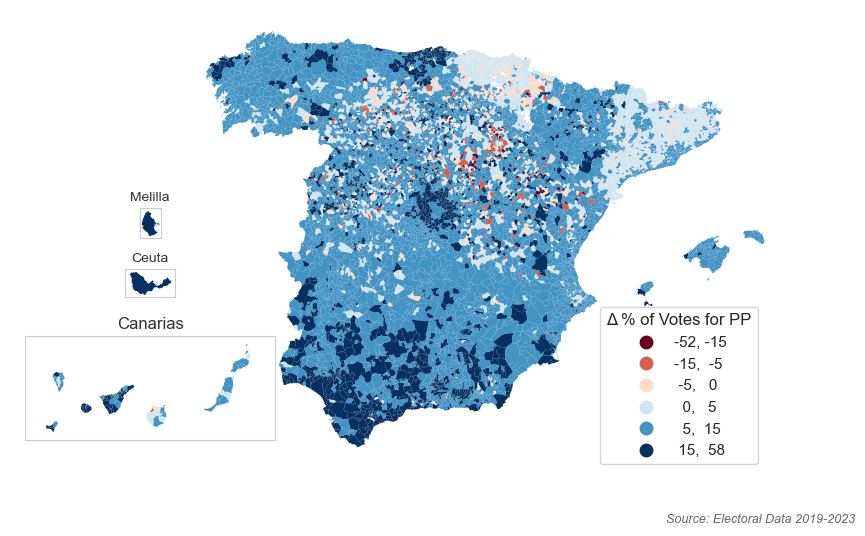

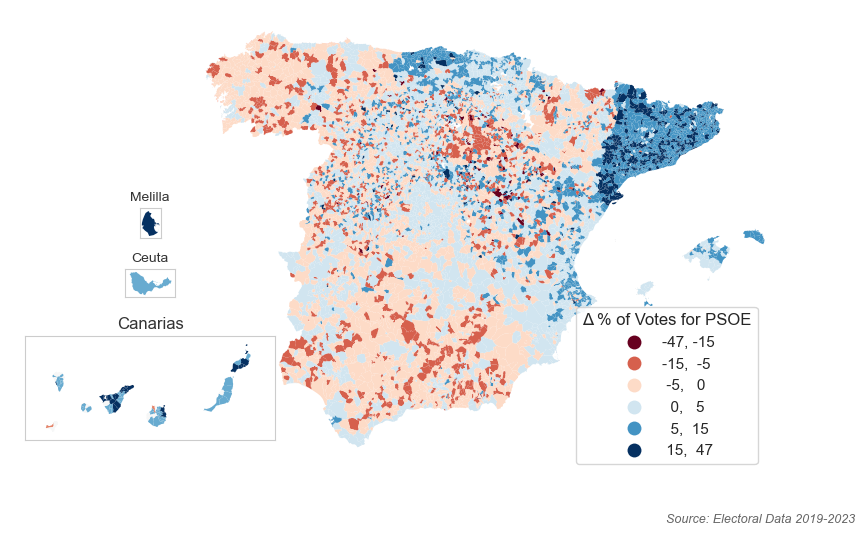

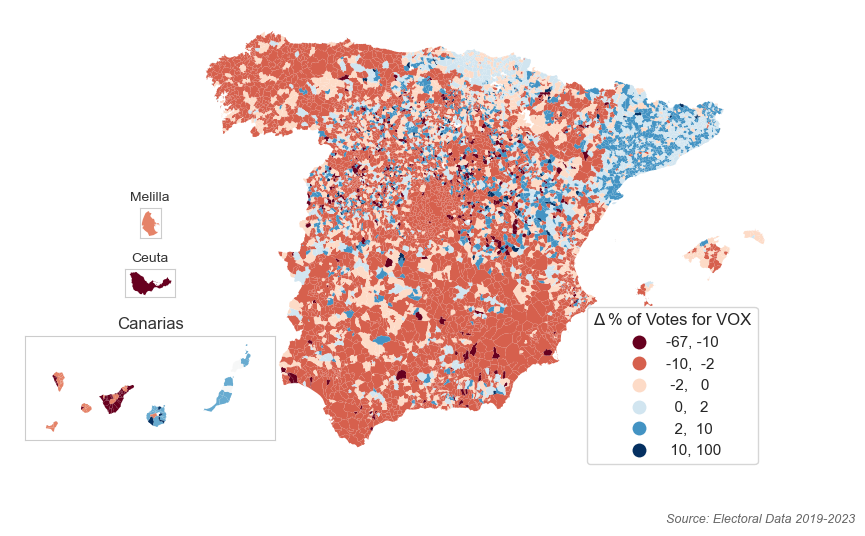

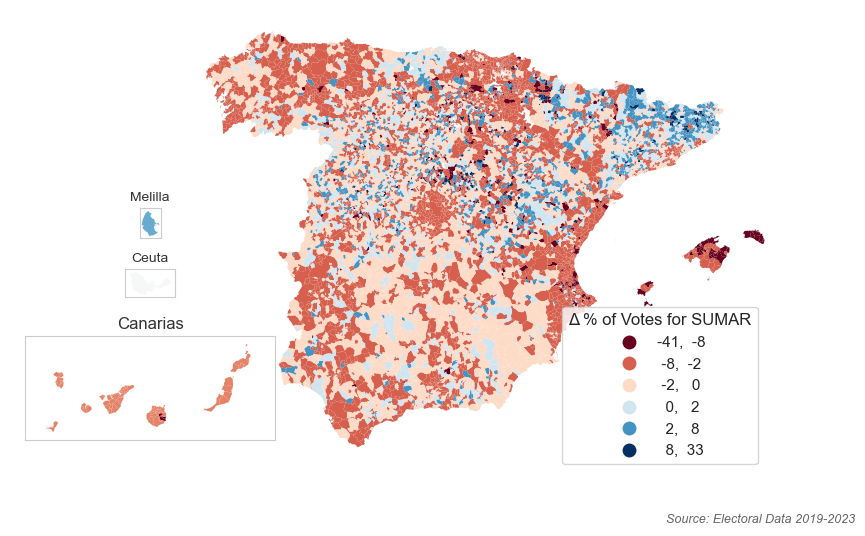

In [ ]:
### Electoral Vote Differences (2023 vs 2019)
# Create four choropleth maps showing vote share changes for each party

# Define the parties and their difference metadata
party_diff_maps_config = [
    {
        'variable': V_PP_DIFF_2023_2019,
        'party_name': 'PP',
        'bins': [-15, -5, 0, 5, 15],
        'cmap': 'RdBu',
        'filename': '02_images/02_map_PP_diff_2023_2019.png'
    },
    {
        'variable': V_PSOE_DIFF_2023_2019,
        'party_name': 'PSOE',
        'bins': [-15, -5, 0, 5, 15],
        'cmap': 'RdBu',
        'filename': '02_images/02_map_PSOE_diff_2023_2019.png'
    },
    {
        'variable': V_VOX_DIFF_2023_2019,
        'party_name': 'VOX',
        'bins': [-10, -2, 0, 2, 10],
        'cmap': 'RdBu',
        'filename': '02_images/02_map_VOX_diff_2023_2019.png'
    },
    {
        'variable': V_SUMAR_DIFF_2023_2019,
        'party_name': 'SUMAR',
        'bins': [-8, -2, 0, 2, 8],
        'cmap': 'RdBu',
        'filename': '02_images/02_map_SUMAR_diff_2023_2019.png'
    }
]

# Generate difference maps for each party
for config in party_diff_maps_config:
    plot, ax = plt.subplots(figsize=(10, 6))
    plot_spanish_map(
        gdf,
        variable=config['variable'],
        bins=config['bins'],
        cmap=config['cmap'],
        legend_title=f'Δ % of Votes for {config["party_name"]}',
        source_text='Source: Electoral Data 2019-2023',
        ax=ax
    )
    plot.savefig(config['filename'], bbox_inches='tight', dpi=300)
    plt.show()
